In [1]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
from datetime import date

# Load data and get time

### background

#### 17/12

In [2]:
bg = {}

coinc1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Coincidence_histo.txt", skiprows=1)
timestamps1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Timestamp_ch0.txt", skiprows=1)

ctime1 = coinc1[:, 0]
counts1 = coinc1[:, 1]
t1 = timestamps1[:, 0]
time1 = (t1[-1] - t1[0]) * 1e-12

bg["d"] = {
    "ctime": ctime1,
    "counts": counts1,
    "time": time1
}

#### 18/03

In [3]:
coinc2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Coincidence_histo.txt", skiprows=1)
timestamps2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Timestamp_ch0.txt", skiprows=1)

ctime2 = coinc2[:, 0]
counts2 = coinc2[:, 1]
t2 = timestamps2[:, 0]
time2 = (t2[-1] - t2[0]) * 1e-12

bg["m"] = {
    "ctime": ctime2,
    "counts": counts2,
    "time": time2
}

#### 01/04

In [4]:
coinc3 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\01_04_background\Coincidence_histo.txt", skiprows=1)
timestamps3 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\01_04_background\Timestamp_ch0.txt", skiprows=1)

ctime3 = coinc3[:, 0]
counts3 = coinc3[:, 1]
t3 = timestamps3[:, 0]
time3 = (t3[-1] - t3[0]) * 1e-12

bg["a1"] = {
    "ctime": ctime3,
    "counts": counts3,
    "time": time3
}

#### 22/04

In [5]:
coinc4 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\22_04_bg_10min\Coincidence_histo.txt", skiprows=1)
timestamps4 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\22_04_bg_10min\Timestamp_ch0.txt", skiprows=1)

ctime4 = coinc4[:, 0]
counts4 = coinc4[:, 1]
t4 = timestamps4[:, 0]
time4 = (t4[-1] - t4[0]) * 1e-12

bg["min10"] = {
    "ctime": ctime4,
    "counts": counts4,
    "time": time4
}

### Na22

#### 17/12

In [6]:
na22d = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 Na22 pos{}"

for i in range(1, 10):
    path = base_path.format(i)
    
    coinc = np.loadtxt(f"{path}\\Coincidence_histo.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    ctime = coinc[:, 0]
    counts = coinc[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22d[f"{i}"] = {
        "ctime": ctime,
        "counts": counts,
        "time": time
    }

#### 18/03

In [7]:
na22m = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_Na22Pos{}"

for i in range(1, 21):
    path = base_path.format(i)
    
    coinc = np.loadtxt(f"{path}\\Coincidence_histo.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    ctime = coinc[:, 0]
    counts = coinc[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22m[f"{i}"] = {
        "ctime": ctime,
        "counts": counts,
        "time": time
    }

#### 01/04

In [8]:
na22a1 = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\01_04_Na22_pos{}"

for i in range(1, 15):
    path = base_path.format(i)
    
    coinc = np.loadtxt(f"{path}\\Coincidence_histo.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    ctime = coinc[:, 0]
    counts = coinc[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22a1[f"{i}"] = {
        "ctime": ctime,
        "counts": counts,
        "time": time
    }

#### 22/04

In [9]:
na22min10 = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\22_04_Na22_pos{}"

for i in range(1, 34):
    path = base_path.format(i)
    
    coinc = np.loadtxt(f"{path}\\Coincidence_histo.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    ctime = coinc[:, 0]
    counts = coinc[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22min10[f"{i}"] = {
        "ctime": ctime,
        "counts": counts,
        "time": time
    }

---

# Subtract background

### background

#### 17/12

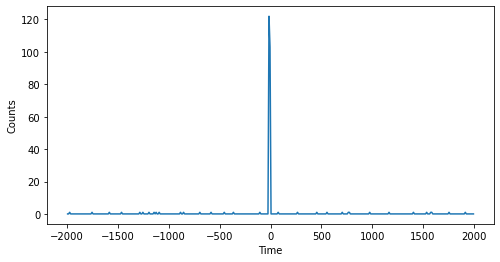

In [10]:
#spectrum background
range_bg = (bg["d"]["ctime"] > -2000) & (bg["d"]["ctime"] < 2000)
plt.figure(figsize=(8, 4))
plt.plot(bg["d"]["ctime"][range_bg], bg["d"]["counts"][range_bg])
plt.xlabel("Time")
plt.ylabel("Counts")
plt.show()

#### 18/03

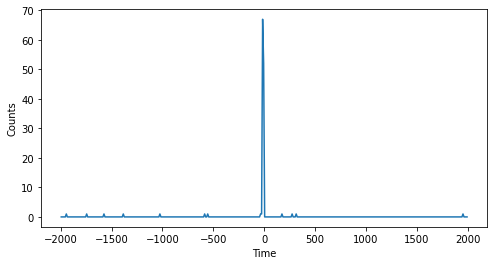

In [11]:
#spectrum background
range_bg = (bg["m"]["ctime"] > -2000) & (bg["m"]["ctime"] < 2000)
plt.figure(figsize=(8, 4))
plt.plot(bg["m"]["ctime"][range_bg], bg["m"]["counts"][range_bg])
plt.xlabel("Time")
plt.ylabel("Counts")
plt.show()

#### 01/04

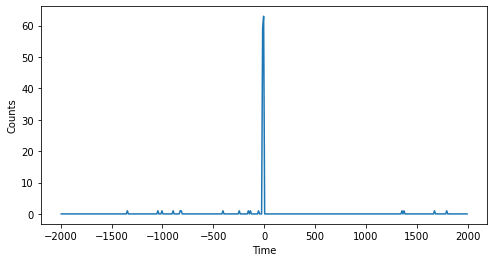

In [12]:
#spectrum background
range_bg = (bg["a1"]["ctime"] > -2000) & (bg["a1"]["ctime"] < 2000)
plt.figure(figsize=(8, 4))
plt.plot(bg["a1"]["ctime"][range_bg], bg["a1"]["counts"][range_bg])
plt.xlabel("Time")
plt.ylabel("Counts")
plt.show()

#### 22/04

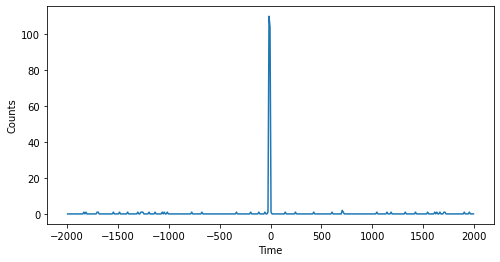

In [13]:
#spectrum background
range_bg = (bg["min10"]["ctime"] > -2000) & (bg["min10"]["ctime"] < 2000)
plt.figure(figsize=(8, 4))
plt.plot(bg["min10"]["ctime"][range_bg], bg["min10"]["counts"][range_bg])
plt.xlabel("Time")
plt.ylabel("Counts")
plt.show()

### Na22

#### 17/12

In [14]:
for key in na22d:
    counts_bg_na22 = bg["d"]["counts"] * (na22d[key]["time"] / bg["d"]["time"])
    na22d[key]["netcounts"] = na22d[key]["counts"] - counts_bg_na22
    na22d[key]["netcounts"][na22d[key]["netcounts"] < 0] = 0

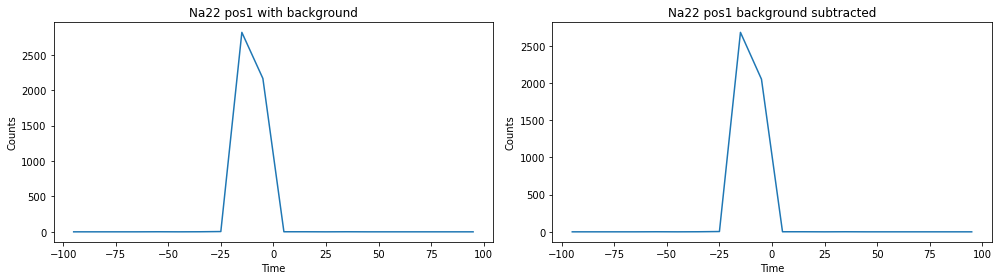

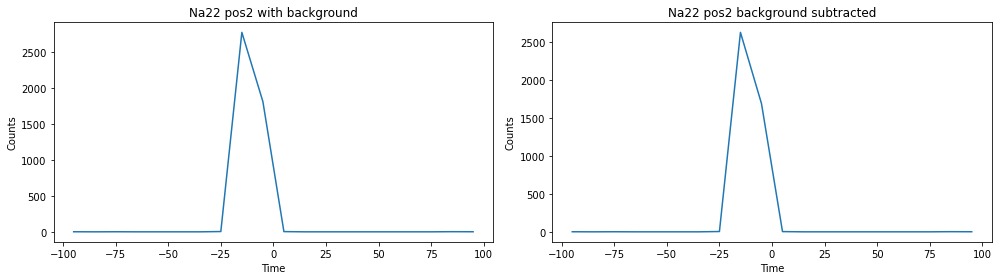

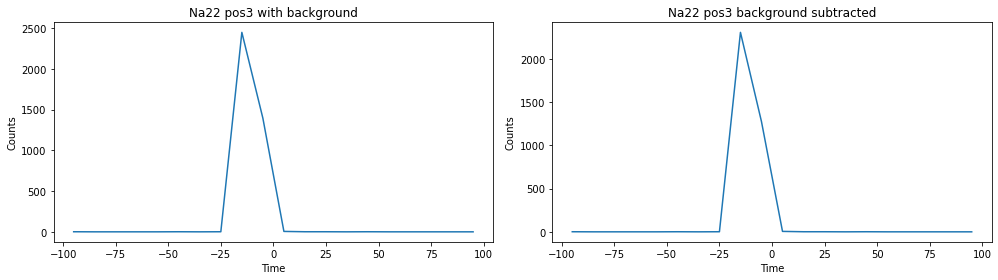

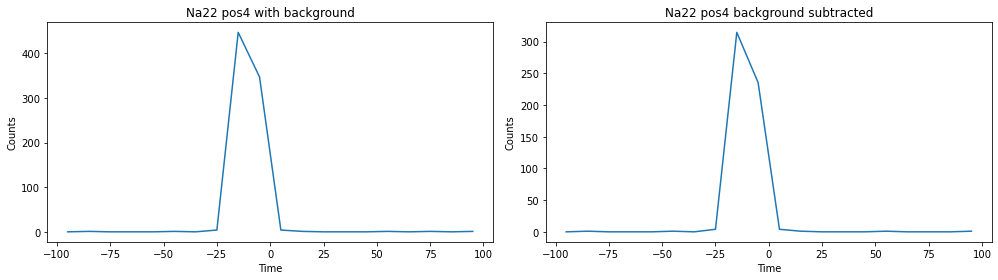

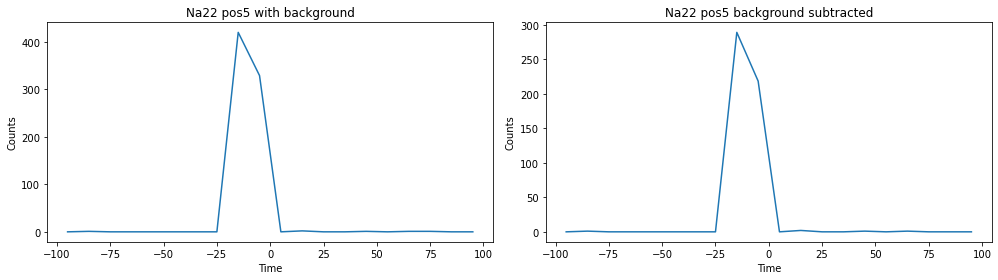

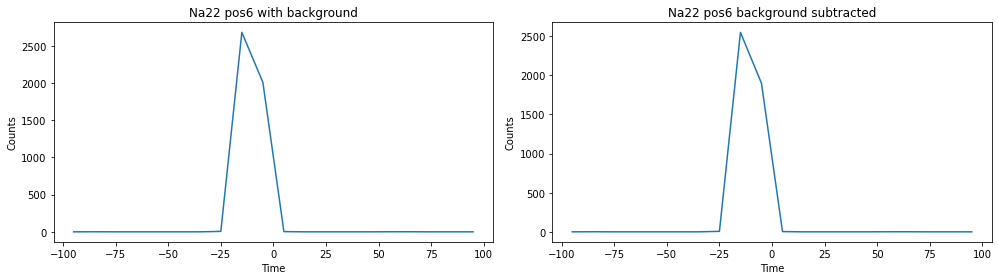

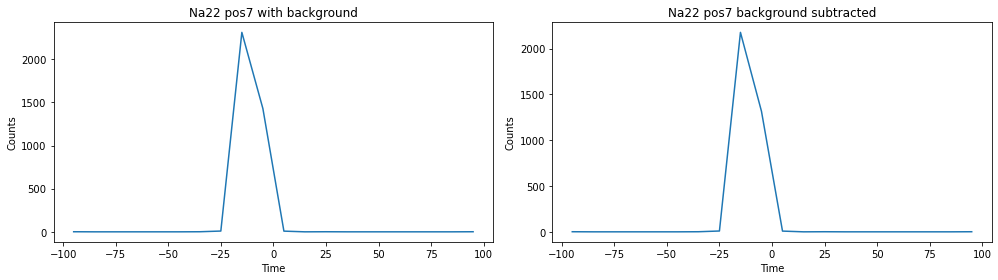

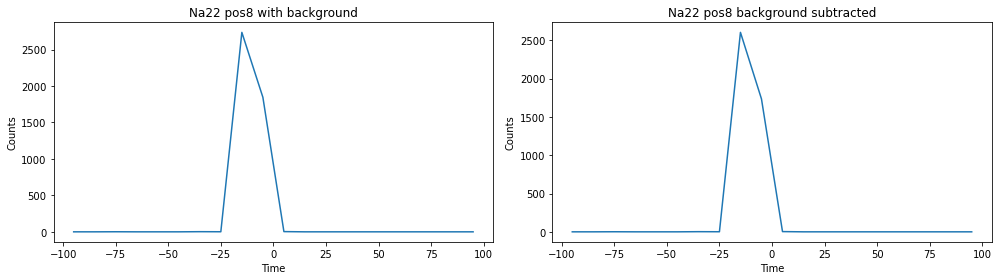

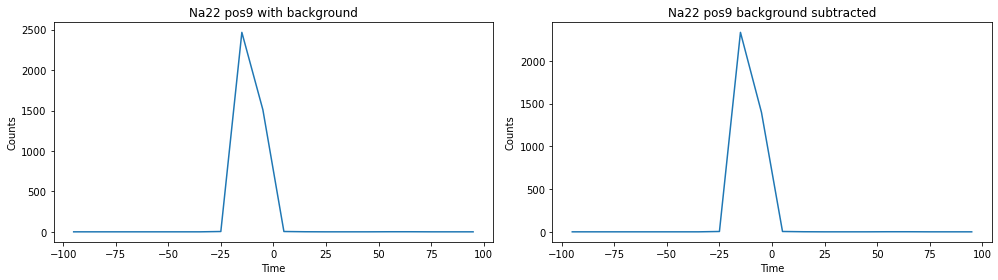

In [15]:
for key in na22d:
    range_na22 = (na22d[key]["ctime"] > -100) & (na22d[key]["ctime"] < 100)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22d[key]["ctime"][range_na22], na22d[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22d[key]["ctime"][range_na22], na22d[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("Time")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()

#### 18/03

In [16]:
for key in na22m:
    counts_bg_na22 = bg["m"]["counts"] * (na22m[key]["time"] / bg["m"]["time"])
    na22m[key]["netcounts"] = na22m[key]["counts"] - counts_bg_na22
    na22m[key]["netcounts"][na22m[key]["netcounts"] < 0] = 0

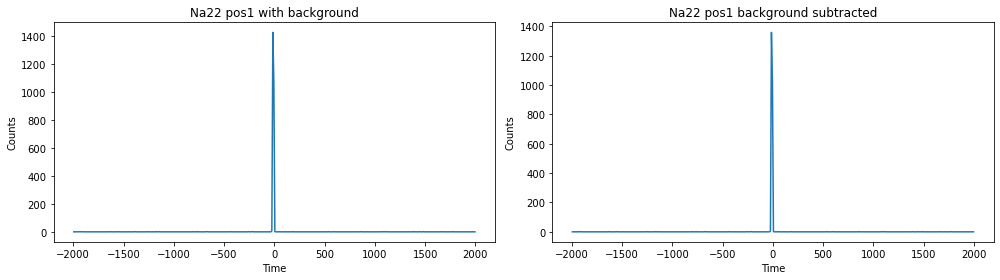

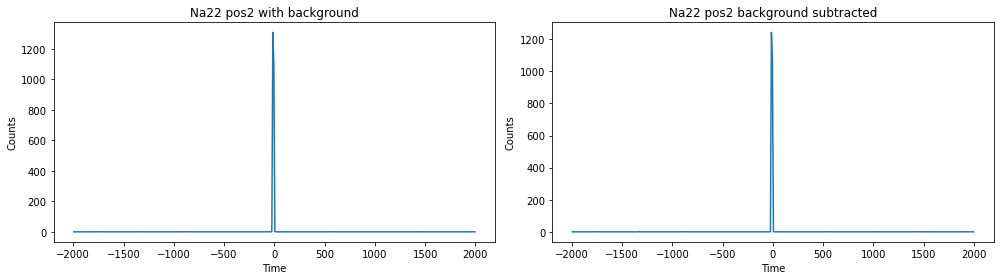

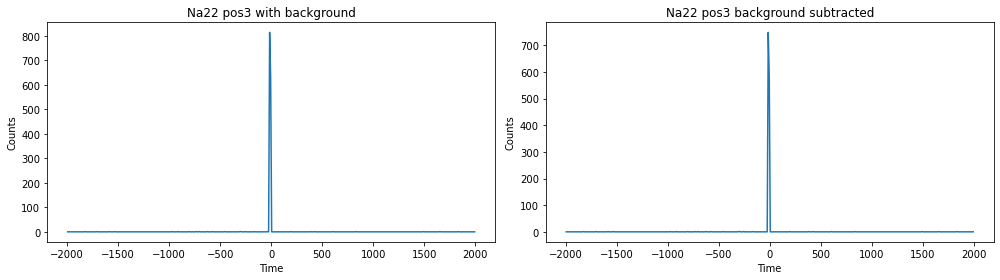

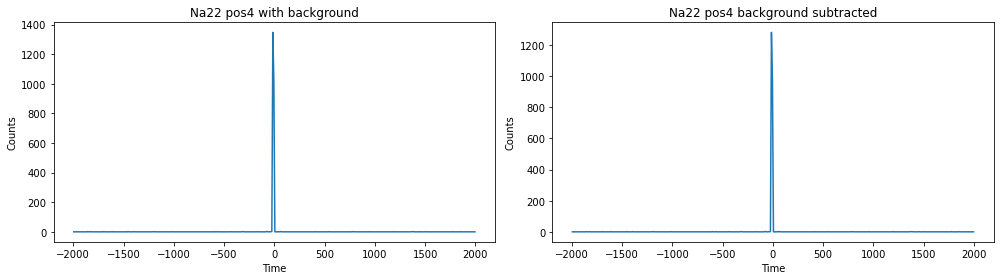

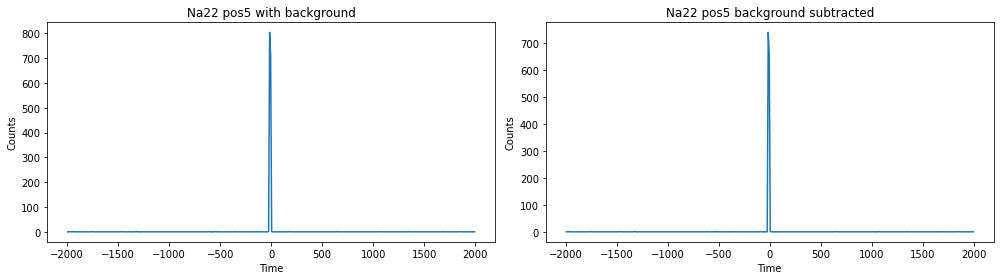

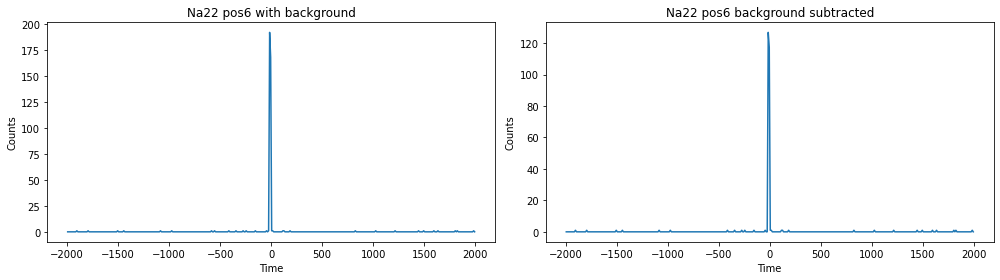

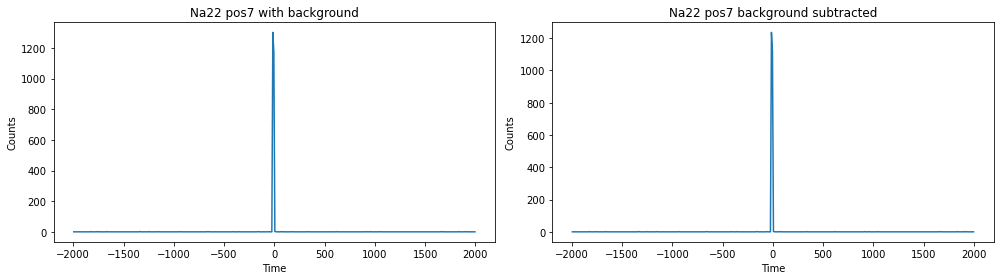

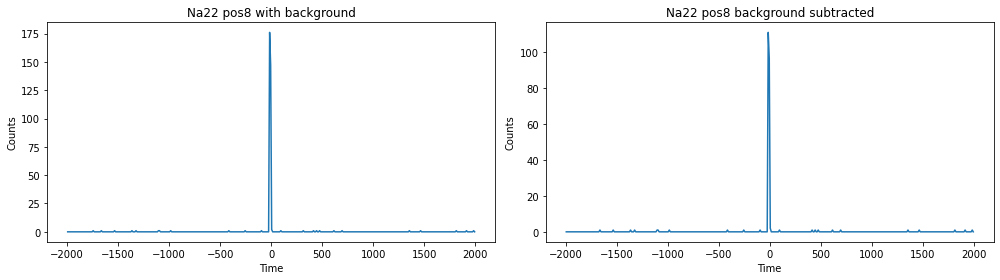

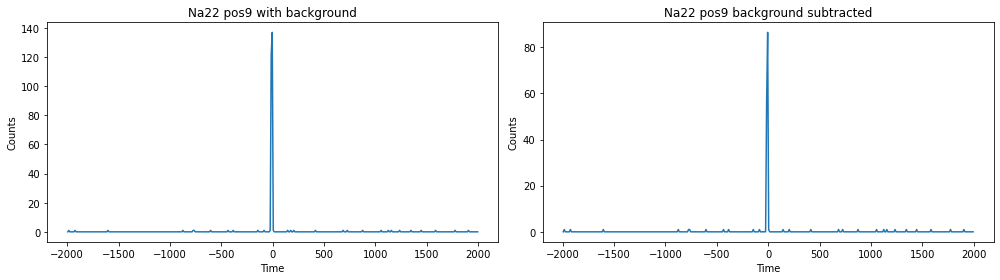

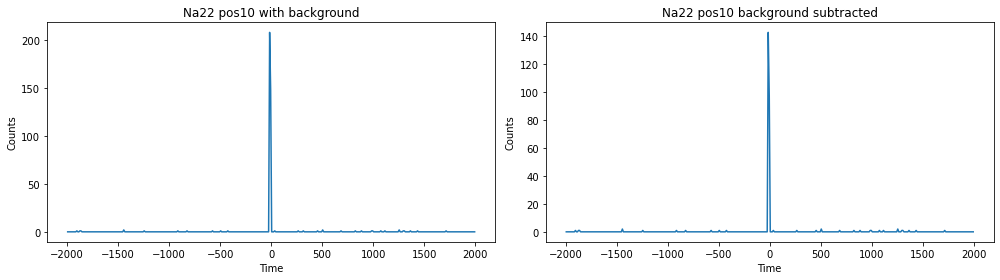

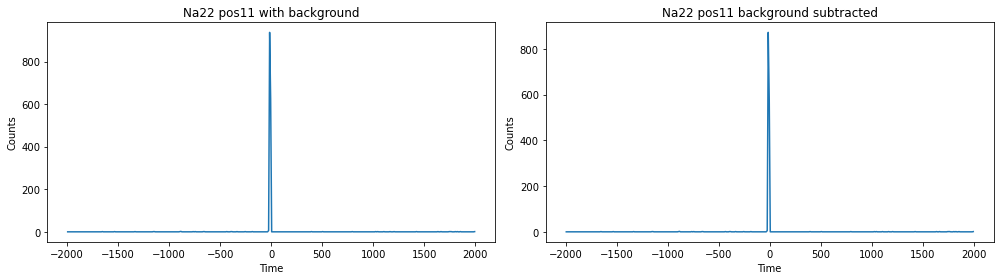

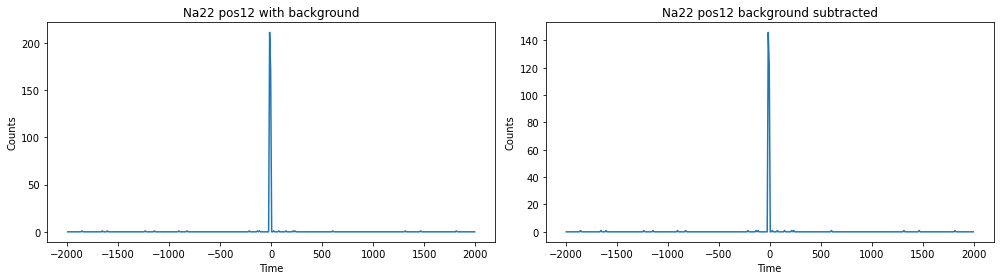

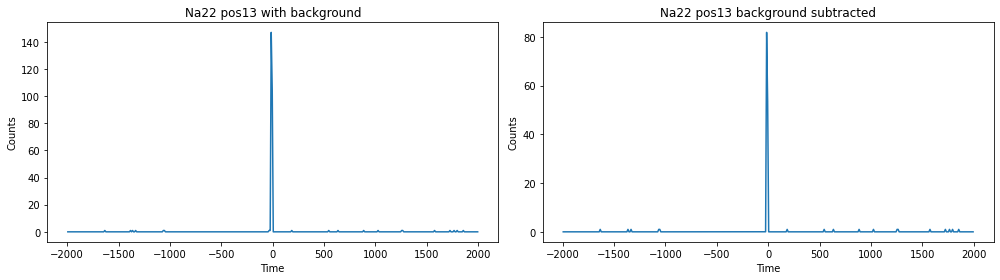

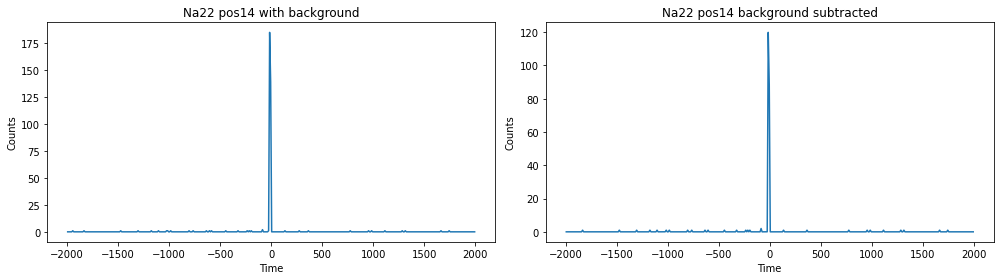

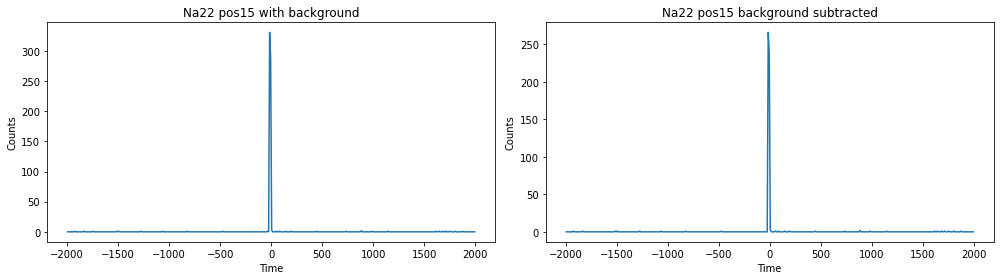

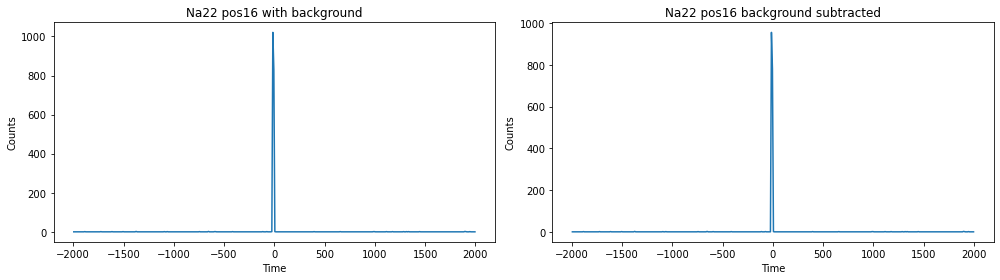

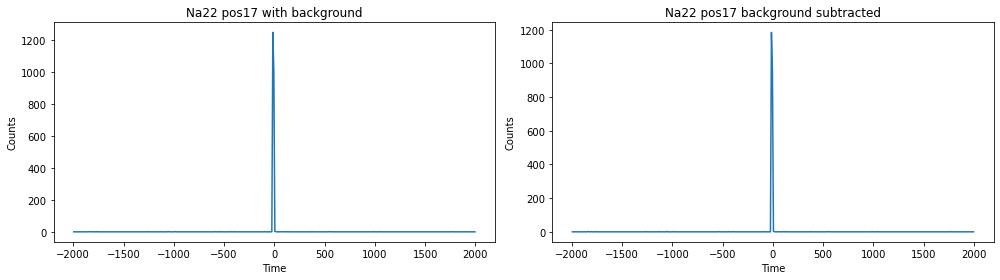

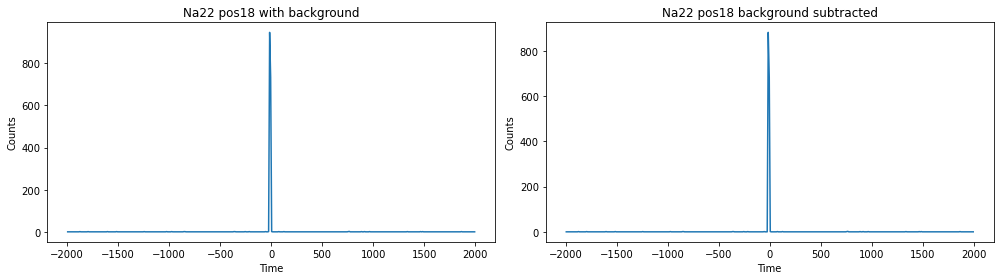

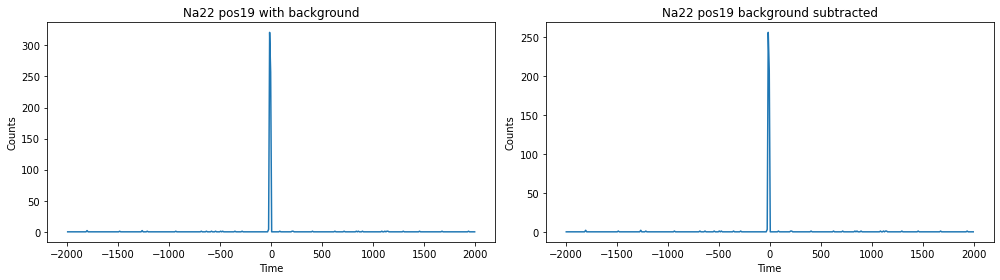

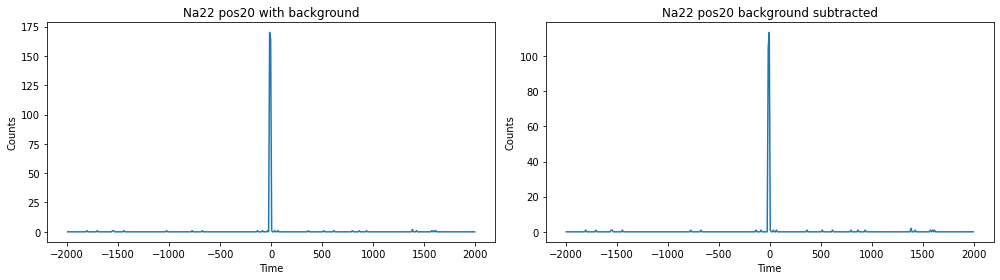

In [17]:
for key in na22m:
    range_na22 = (na22m[key]["ctime"] > -2000) & (na22m[key]["ctime"] < 2000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22m[key]["ctime"][range_na22], na22m[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22m[key]["ctime"][range_na22], na22m[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("Time")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    display(plt.gcf())  
    plt.close()

#### 01/04

In [18]:
for key in na22a1:
    counts_bg_na22 = bg["a1"]["counts"] * (na22a1[key]["time"] / bg["a1"]["time"])
    na22a1[key]["netcounts"] = na22a1[key]["counts"] - counts_bg_na22
    na22a1[key]["netcounts"][na22a1[key]["netcounts"] < 0] = 0

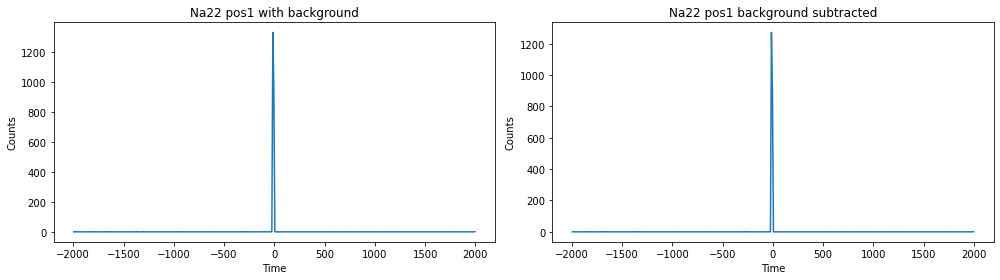

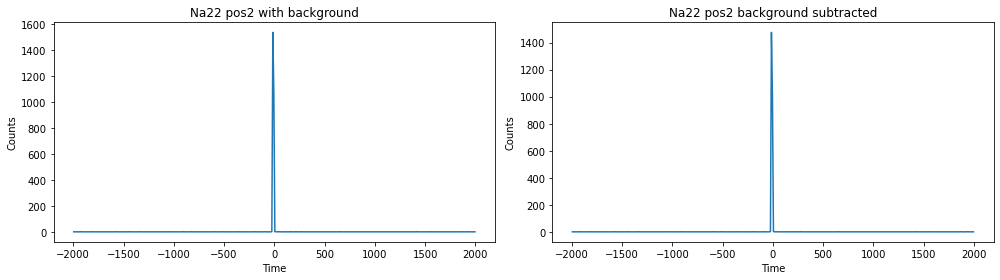

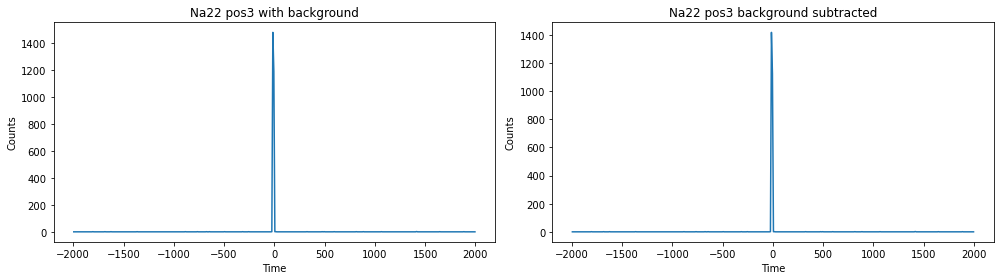

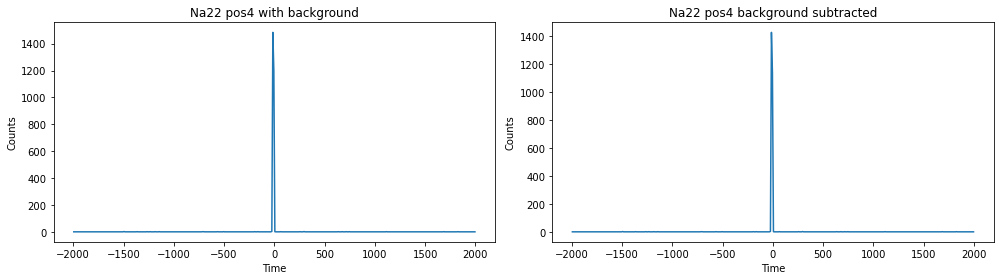

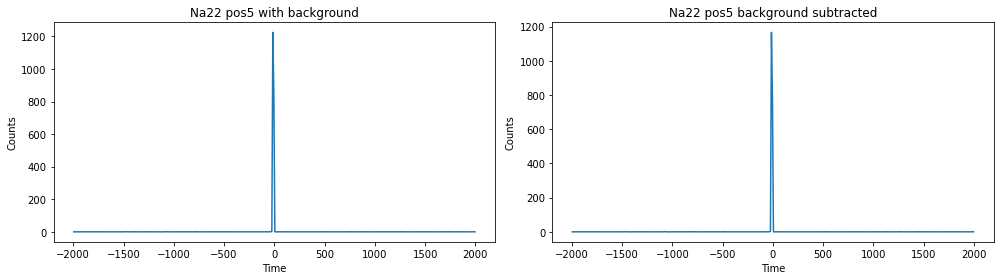

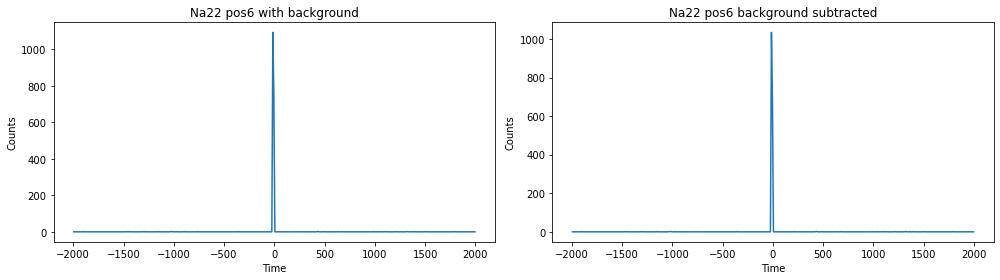

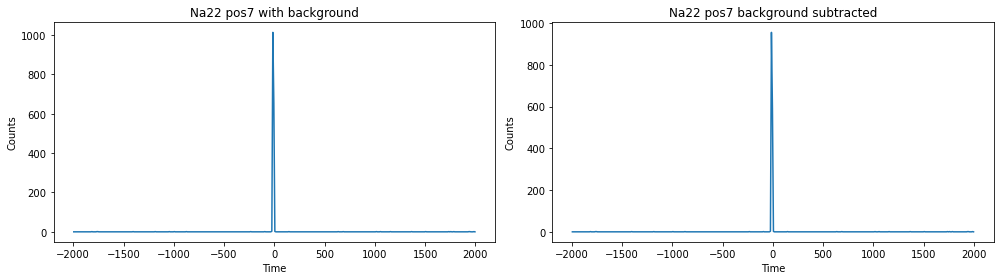

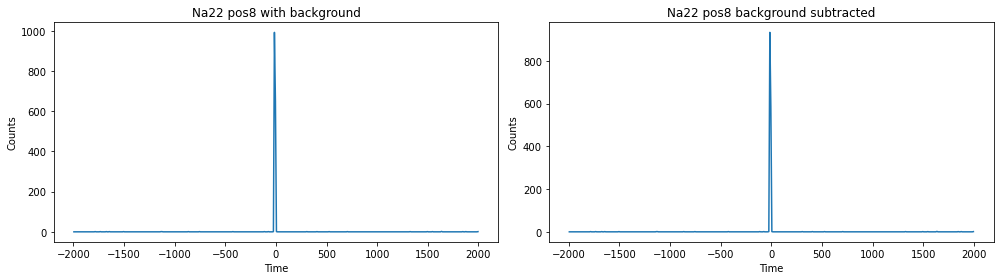

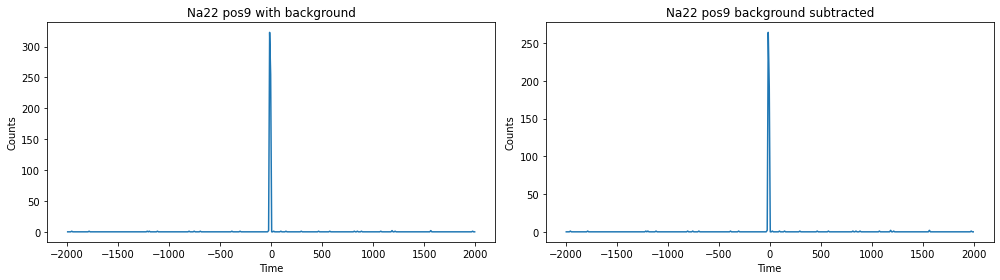

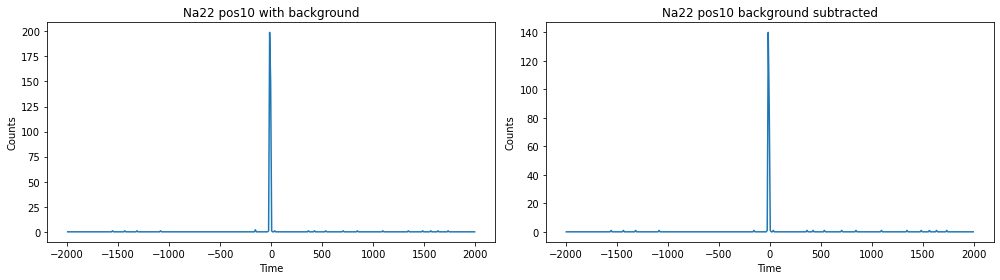

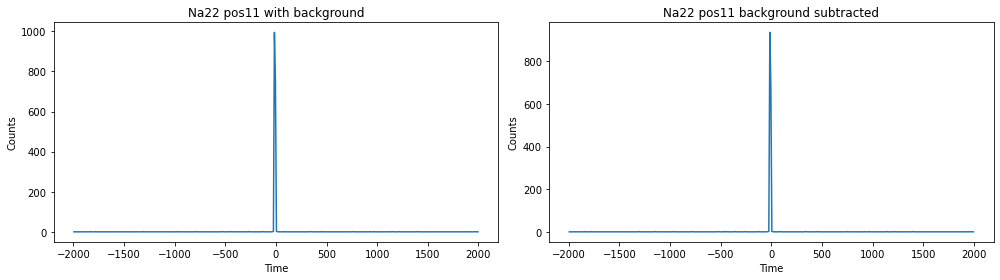

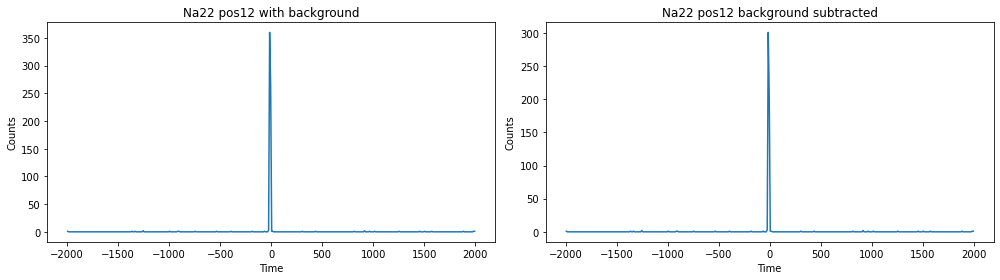

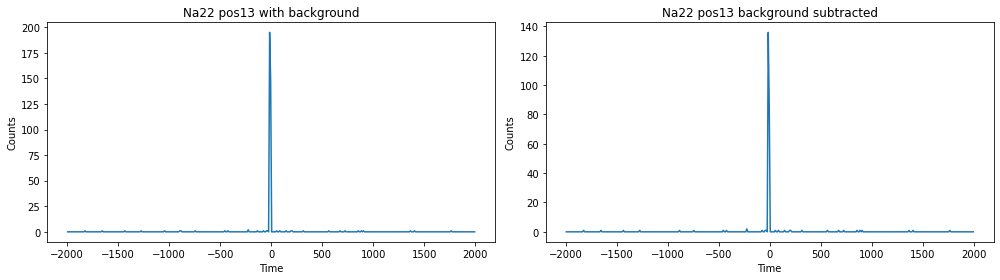

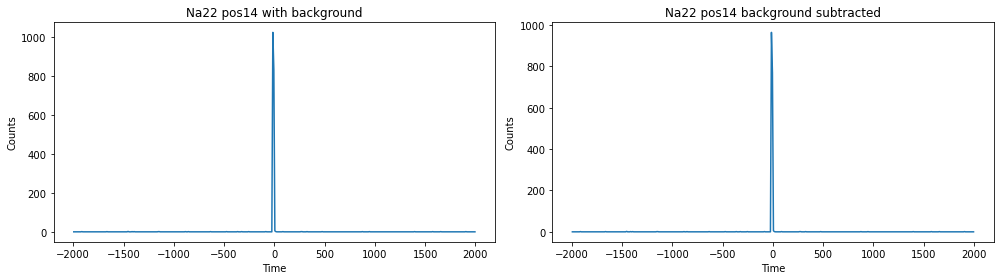

In [19]:
for key in na22a1:
    range_na22 = (na22a1[key]["ctime"] > -2000) & (na22a1[key]["ctime"] < 2000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22a1[key]["ctime"][range_na22], na22a1[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22a1[key]["ctime"][range_na22], na22a1[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("Time")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    display(plt.gcf())  
    plt.close()

#### 22/04

In [20]:
for key in na22min10:
    counts_bg_na22 = bg["min10"]["counts"] * (na22min10[key]["time"] / bg["min10"]["time"])
    na22min10[key]["netcounts"] = na22min10[key]["counts"] - counts_bg_na22
    na22min10[key]["netcounts"][na22min10[key]["netcounts"] < 0] = 0

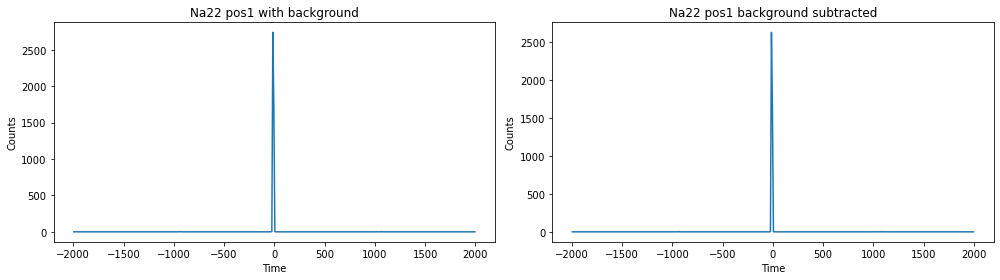

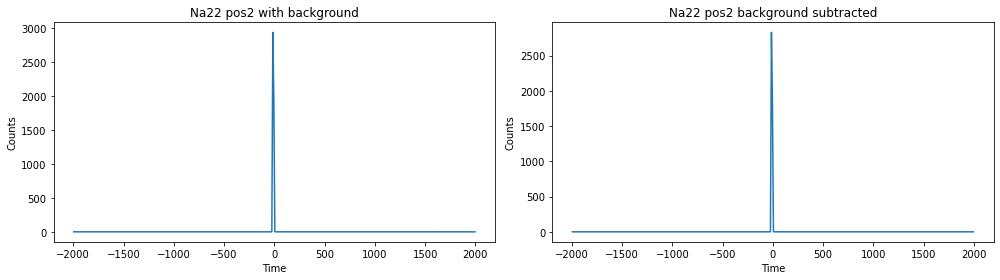

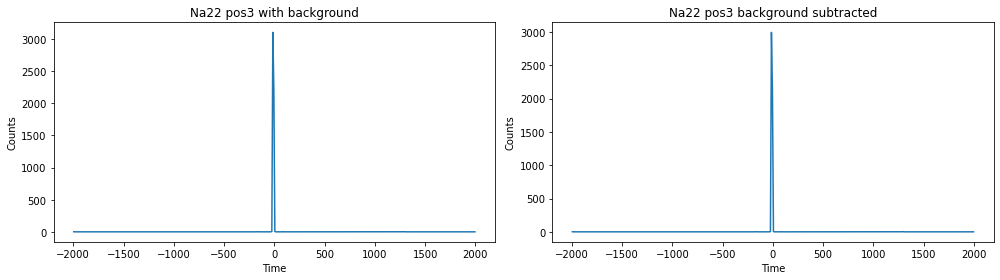

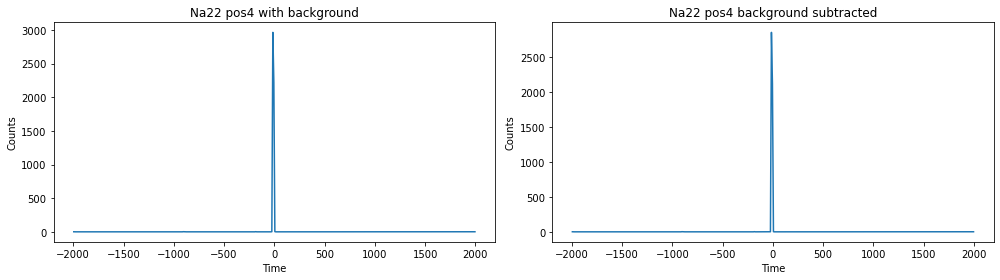

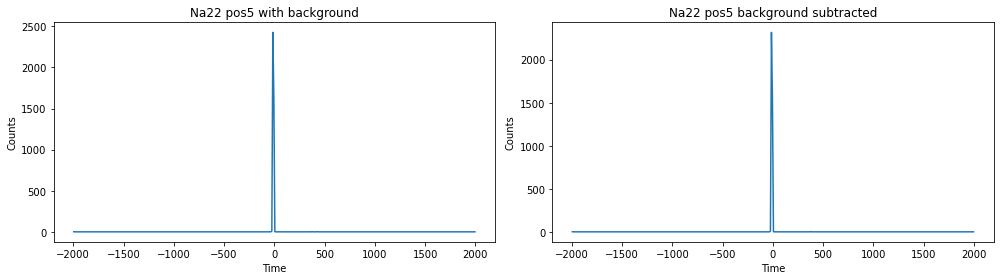

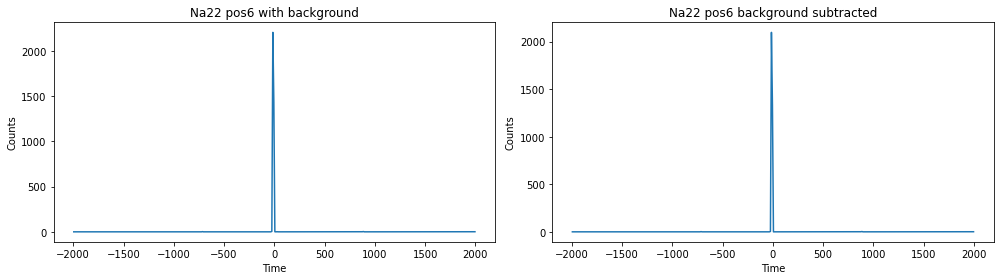

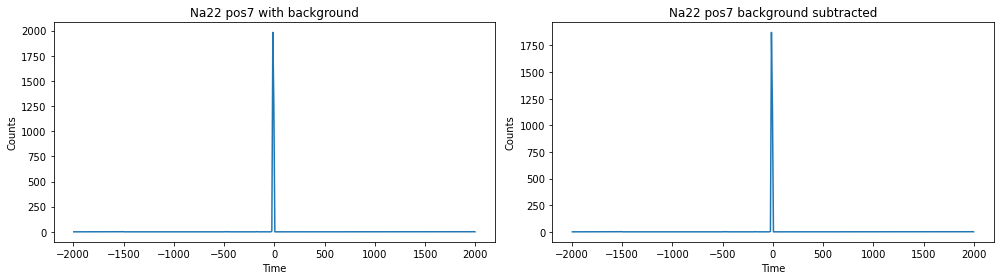

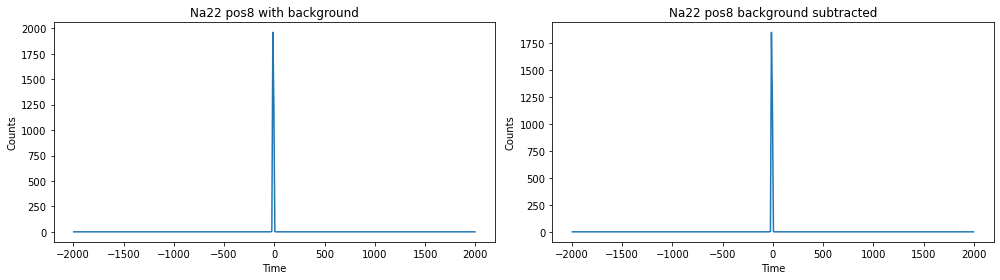

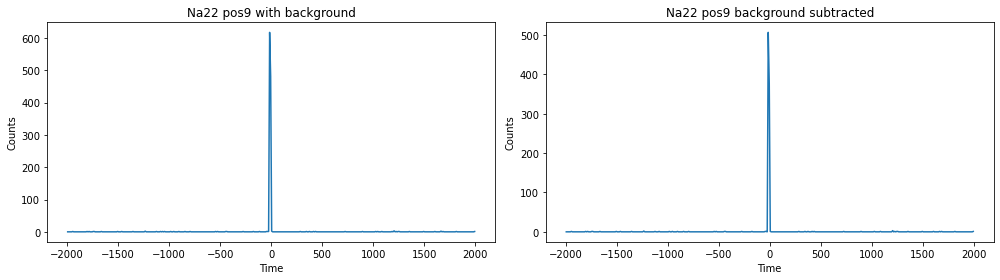

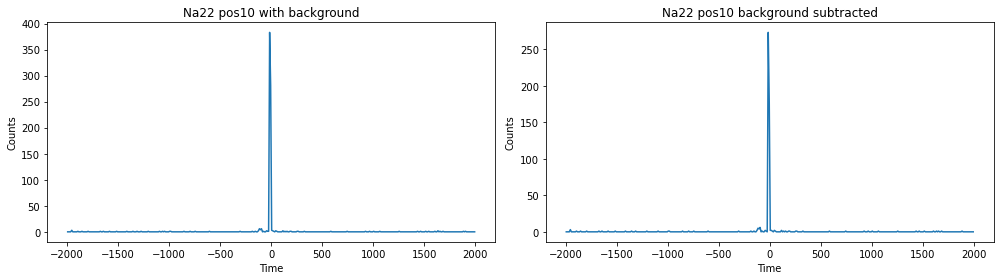

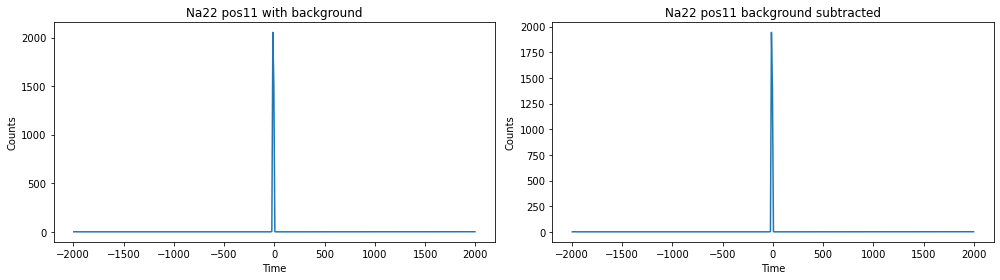

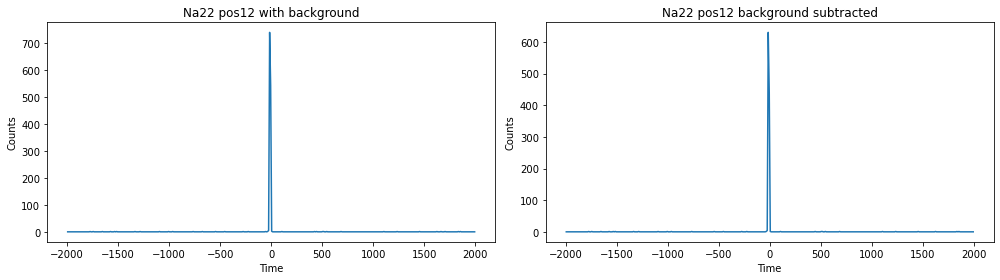

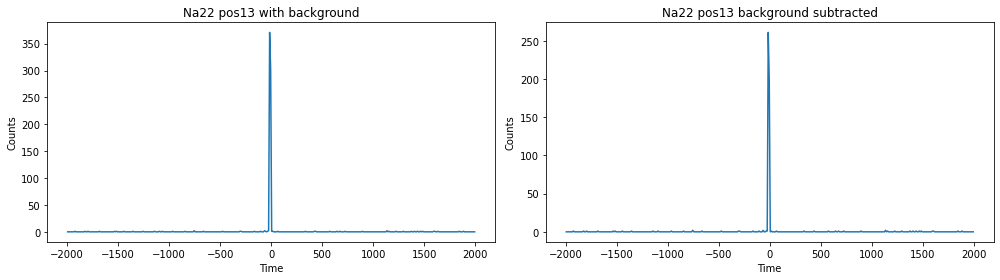

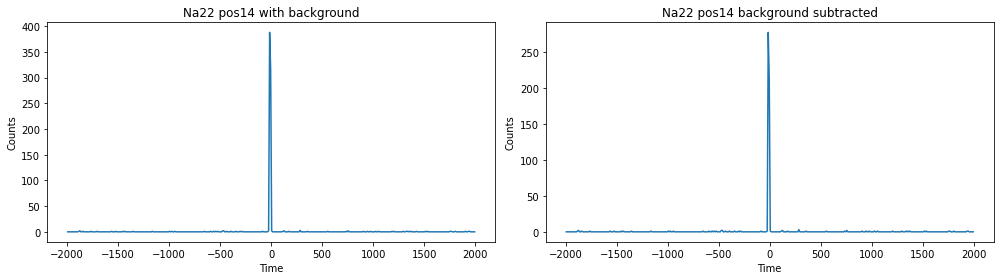

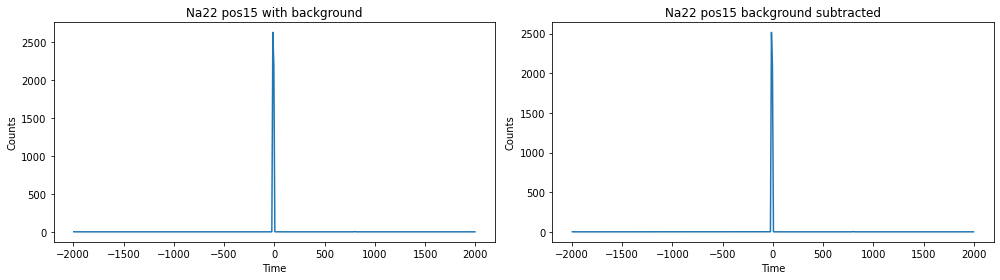

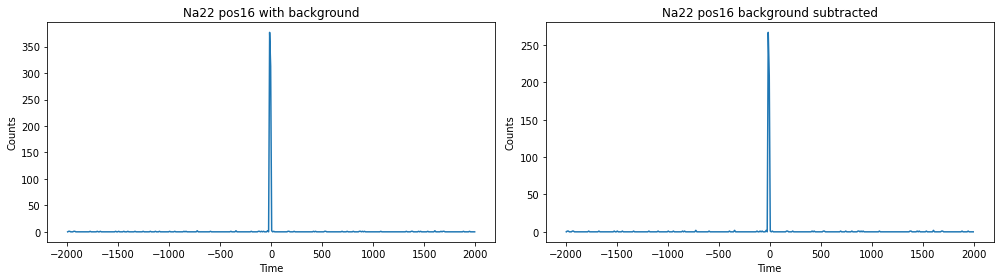

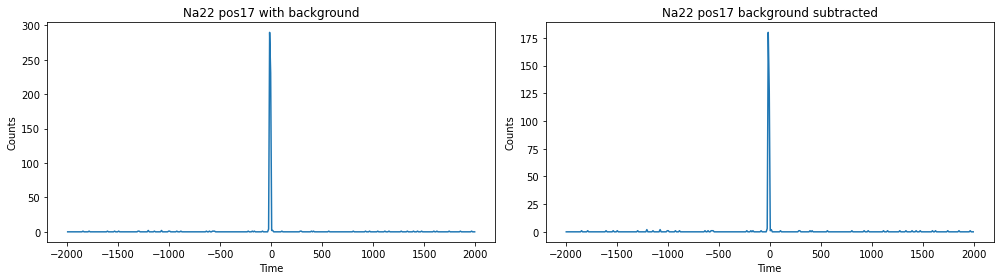

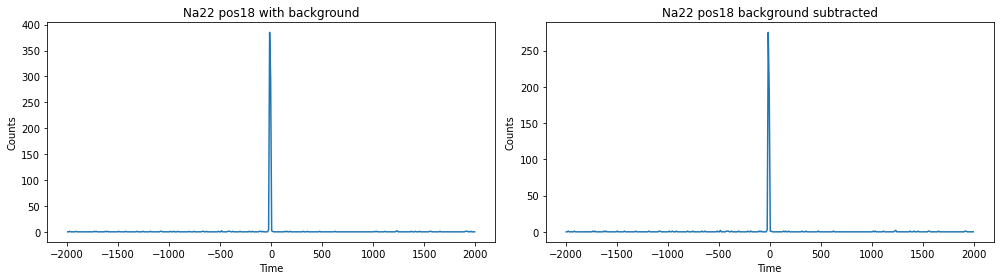

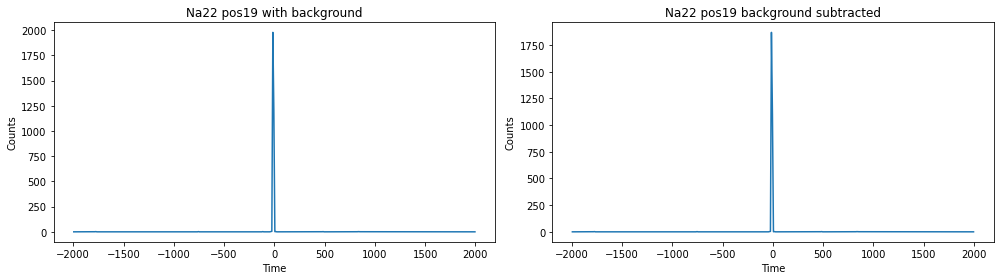

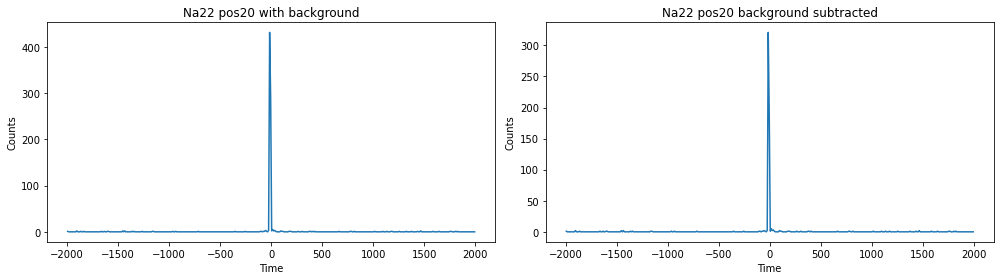

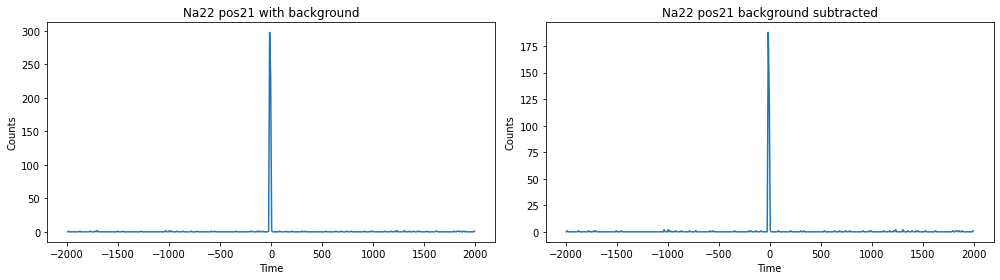

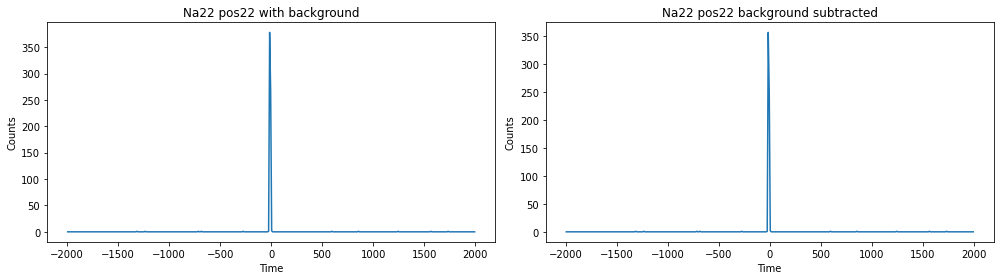

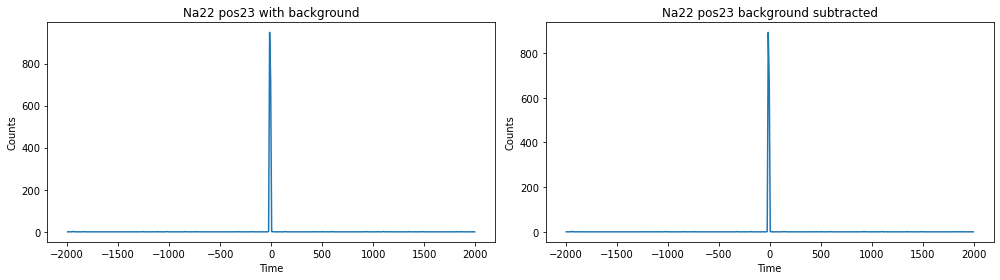

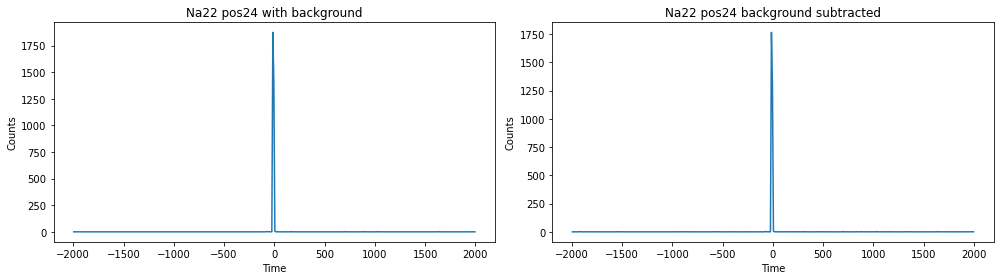

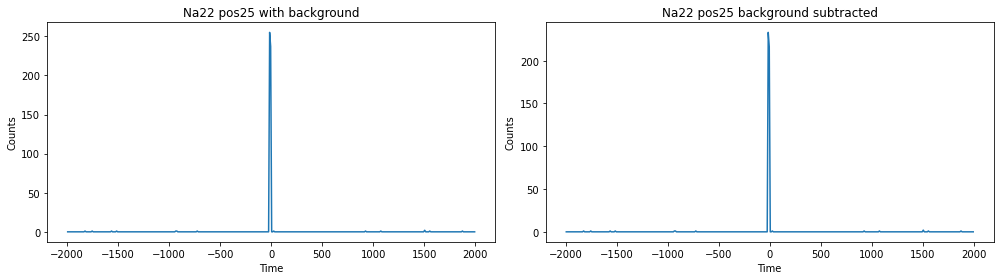

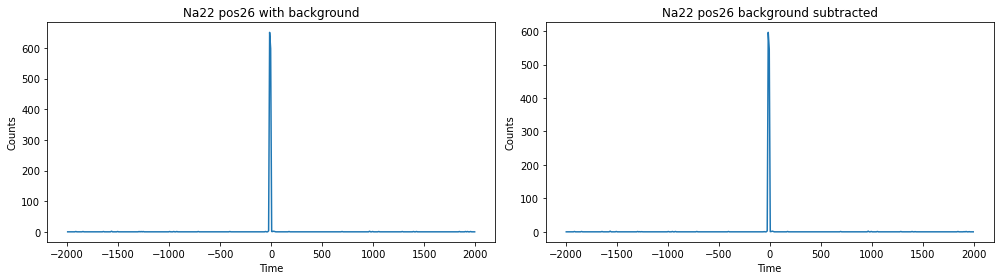

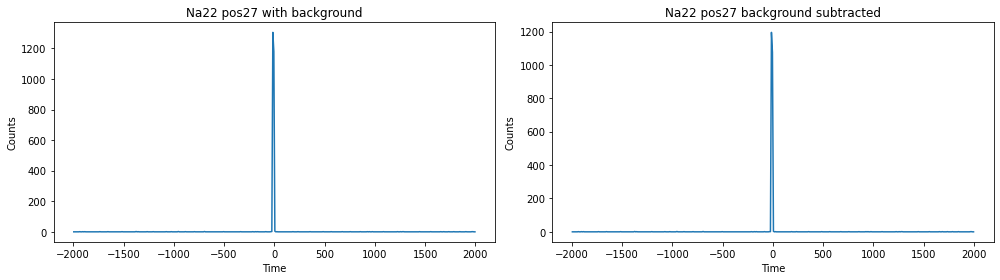

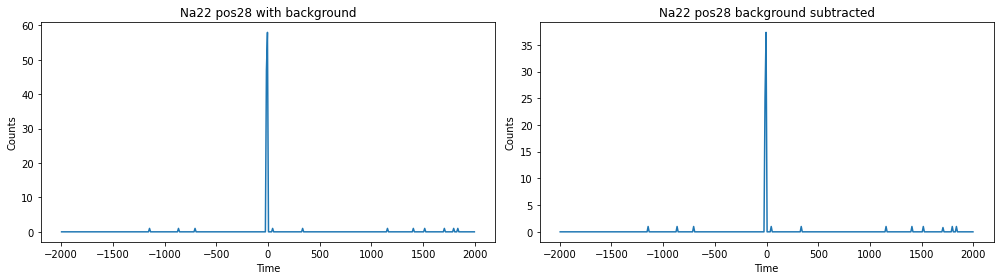

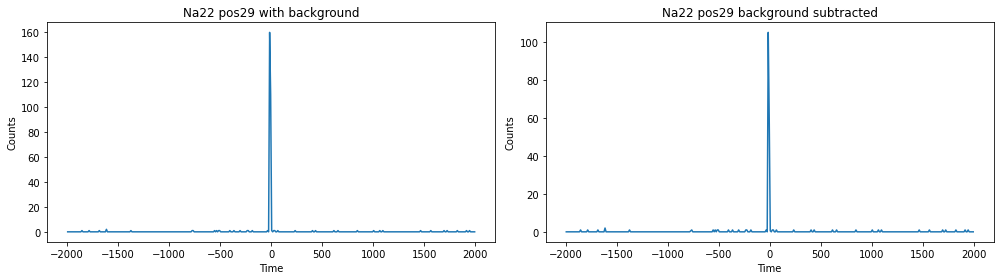

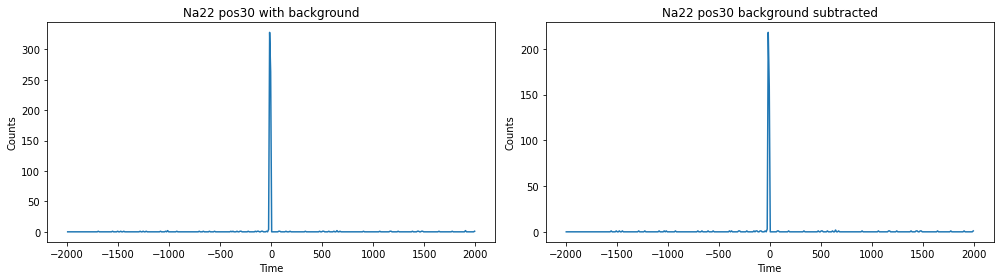

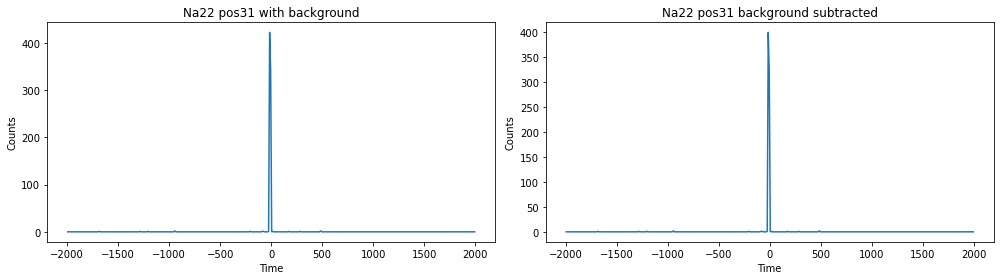

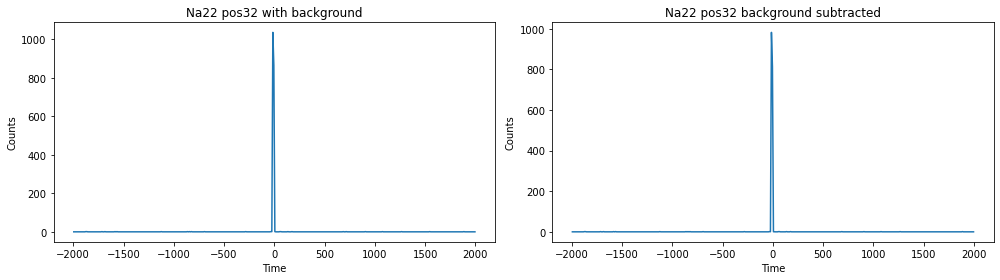

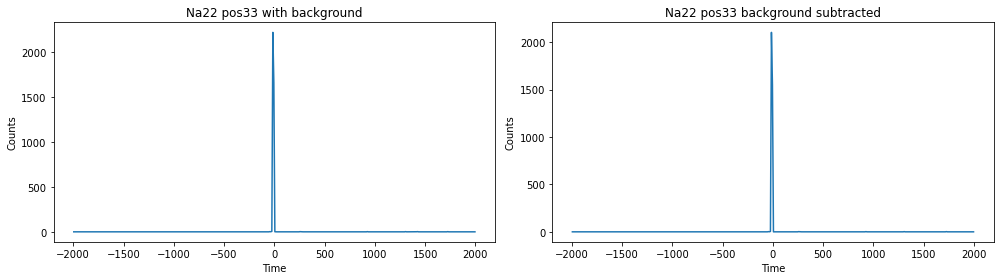

In [21]:
for key in na22min10:
    range_na22 = (na22min10[key]["ctime"] > -2000) & (na22min10[key]["ctime"] < 2000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22min10[key]["ctime"][range_na22], na22min10[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22min10[key]["ctime"][range_na22], na22min10[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("Time")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    display(plt.gcf())  
    plt.close()

---

# Statistical errors

#### 17/12

In [22]:
for key in na22d:
    na22d[key]["sigma_counts"] = np.sqrt(na22d[key]["counts"] + (na22d[key]["time"] / bg["d"]["time"])**2 * bg["d"]["counts"])
    na22d[key]["sigma_counts"][na22d[key]["sigma_counts"] == 0] = 1

#### 18/03

In [23]:
for key in na22m:
    na22m[key]["sigma_counts"] = np.sqrt(na22m[key]["counts"] + (na22m[key]["time"] / bg["m"]["time"])**2 * bg["m"]["counts"])
    na22m[key]["sigma_counts"][na22m[key]["sigma_counts"] == 0] = 1

#### 01/04

In [24]:
for key in na22a1:
    na22a1[key]["sigma_counts"] = np.sqrt(na22a1[key]["counts"] + (na22a1[key]["time"] / bg["a1"]["time"])**2 * bg["a1"]["counts"])
    na22a1[key]["sigma_counts"][na22a1[key]["sigma_counts"] == 0] = 1

#### 22/04

In [25]:
for key in na22min10:
    na22min10[key]["sigma_counts"] = np.sqrt(na22min10[key]["counts"] + (na22min10[key]["time"] / bg["min10"]["time"])**2 * bg["min10"]["counts"])
    na22min10[key]["sigma_counts"][na22min10[key]["sigma_counts"] == 0] = 1

---

# Get counts

#### 17/12

In [26]:
for key in na22d:
    indices = np.argsort(na22d[key]["netcounts"])[-5:][::-1]
    print(indices)

[198 199 197 129 217]
[198 199 197 200 373]
[198 199 200  77 372]
[198 199 197 200 344]
[198 199 147 201  40]
[198 199 197 200 221]
[198 199 197 200 311]
[198 199 200 174 171]
[198 199 200 197 188]


In [27]:
countsd = []
counts_errd = []
for key in na22d:
    counts = na22d[key]["netcounts"][198] + na22d[key]["netcounts"][199]
    countsd.append(counts)
    error = np.sqrt(na22d[key]["sigma_counts"][198]**2 + na22d[key]["sigma_counts"][199]**2)
    counts_errd.append(error)
print(countsd)
print(counts_errd)
print(len(countsd))

[4732.100097025379, 4324.5962006379, 3578.9761452681987, 549.717791081606, 508.02266205888765, 4448.070764415494, 3492.8624376458592, 4340.209247100858, 3729.5551589834504]
[72.54502850912434, 69.76138037401724, 64.46834343137905, 32.54561227255953, 31.734669257677098, 70.31250996920551, 63.361300837202414, 69.53814637148407, 65.13637556803893]
9


#### 18/03

In [28]:
for key in na22m:
    indices = np.argsort(na22m[key]["netcounts"])[-5:][::-1]
    print(indices)

[198 199 197 200 309]
[198 199  67 200 197]
[198 199 260 219 170]
[198 199 192 197 168]
[198 199  67 384  53]
[198 199 158 212 175]
[198 199 200  66 133]
[198 199 200 244  63]
[199 198 139 220 161]
[198 199 325  55 250]
[198 199 197 111 166]
[198 199 381 109 117]
[198 199 325 372  36]
[198 199 191 295  16]
[198 199 200 288  50]
[198 199  62 134 389]
[198 199 200  94  73]
[198 199 276 275 348]
[198 199 197  19  73]
[199 198 338 132  29]


In [29]:
countsm = []
counts_errm = []
for key in na22m:
    counts = na22m[key]["netcounts"][198] + na22m[key]["netcounts"][199]
    countsm.append(counts)
    error = np.sqrt(na22m[key]["sigma_counts"][198]**2 + na22m[key]["sigma_counts"][199]**2)
    counts_errm.append(error)
print(countsm)
print(counts_errm)
print(len(countsm))

[2384.3263209481474, 2295.317440688316, 1328.3170547245795, 2257.3224605373107, 1396.3220738001, 244.31666837410603, 2357.3251630569393, 207.3189853167353, 143.32052994515485, 240.32246015057345, 1445.3170551113167, 266.32593498441156, 135.31358027747862, 208.33095444666918, 503.32554863393807, 1736.3224605373107, 2140.327865576567, 1565.3193712804714, 462.3182133892627, 218.32052955841763]
[51.11203709839614, 50.23402831829441, 39.4519752546359, 49.85426603090437, 40.30444880358227, 21.736124370642102, 50.84724758932499, 20.867548920935697, 19.27307953836603, 21.643655934986224, 40.907925280322985, 22.23603127132665, 19.064760863743505, 20.890938910562674, 27.045181415649136, 44.32209202508592, 48.66659360858119, 42.349189455891235, 26.276531330609558, 21.12940121357146]
20


#### 01/04

In [30]:
for key in na22a1:
    indices = np.argsort(na22a1[key]["netcounts"])[-5:][::-1]
    print(indices)

[198 199 323 296 289]
[198 199 197 356  18]
[198 199 341 132 174]
[198 199 197 229  50]
[198 199 197  92 324]
[198 199  98 243 102]
[198 199 197 200 263]
[198 199 363 349 332]
[198 199 318 356 197]
[198 199  91 242 334]
[198 199 197 200 339]
[198 199 197  74 291]
[198 199 177 340 219]
[198 199 200  54 114]


In [31]:
countsa1 = []
counts_erra1 = []
for key in na22a1:
    counts = na22a1[key]["netcounts"][198] + na22a1[key]["netcounts"][199]
    countsa1.append(counts)
    error = np.sqrt(na22a1[key]["sigma_counts"][198]**2 + na22a1[key]["sigma_counts"][199]**2)
    counts_erra1.append(error)
print(countsa1)
print(counts_erra1)
print(len(countsa1))

[2160.98696871418, 2481.988597879847, 2543.997964154771, 2558.994705823437, 1948.98615453925, 1720.9857474517848, 1543.9959274937357, 1517.9975566594028, 455.99714997984086, 225.98737620954853, 1621.9869687141802, 503.99266997820826, 220.98737580164527, 1733.9869687141802]
[49.041065077785184, 52.21132832351565, 52.801553686652355, 52.9434659668487, 46.82977356866874, 44.328642058622464, 42.28484533669804, 41.97624193195632, 26.457620832321584, 21.68006570301698, 43.197523817500944, 27.349856681233028, 21.564444108370243, 44.475004934947016]
14


#### 22/04

In [32]:
for key in na22min10:
    indices = np.argsort(na22min10[key]["netcounts"])[-5:][::-1]
    print(indices)

[198 199 197 106 306]
[198 199 197 206 319]
[198 199 197 200 329]
[198 199 181 109 200]
[198 199 197 237 200]
[198 199 197 288 128]
[198 199 197 182 398]
[198 199 197 200 319]
[198 199 320  76 182]
[198 199 190 188 189]
[198 199 197 200   2]
[198 199 197  46  90]
[198 199 313 124 193]
[198 199 228 212 275]
[198 199 280 279 200]
[198 199 360 196 165]
[198 199 197  79 201]
[198 199 197 151 323]
[198 199 197 201 306]
[198 199 201 203  56]
[198 199 330  96 100]
[198 199 200 285 259]
[198 199   5 197 382]
[198 199 200 288 364]
[198 199 350 387 106]
[198 199 197 202  43]
[198 199 200 130  62]
[199 198 351 129 315]
[198 199  38 261 372]
[198 199 197 264 390]
[198 199 248 105  31]
[198 199  87 113 326]
[198 199 197 372 292]


In [33]:
countsmin10 = []
counts_errmin10 = []
for key in na22min10:
    counts = na22min10[key]["netcounts"][198] + na22min10[key]["netcounts"][199]
    countsmin10.append(counts)
    error = np.sqrt(na22min10[key]["sigma_counts"][198]**2 + na22min10[key]["sigma_counts"][199]**2)
    counts_errmin10.append(error)
print(countsmin10)
print(counts_errmin10)
print(len(countsmin10))

[4249.005353261741, 4659.003211885606, 5108.997144593691, 4968.9900067923045, 3858.000356479297, 3422.998215460355, 3031.995716890536, 3013.9999996428064, 883.997501430181, 449.9971445936908, 3342.9928618414206, 1068.9985722968454, 458.9910773017757, 489.9896495986211, 4610.998929133336, 475.9971445936908, 306.9996428063161, 466.00035647929656, 2966.001427345961, 506.997501430181, 316.99214816844005, 602.4572546059737, 1561.156058813489, 3070.003925558586, 449.4469381379947, 1142.155701976999, 2269.997501430181, 62.454407772312905, 163.17317553482246, 377.00428239507653, 720.4515627246205, 1795.1557023341925, 3655.9900064351114]
[68.3885172643071, 71.32316297162511, 74.41105906282155, 73.46441306429968, 65.46754376820626, 62.05645469324018, 58.82183749513995, 58.66856058157885, 36.221609533106204, 29.631161145839666, 61.40858471382693, 38.69112114446716, 29.782844823295157, 30.298856435571444, 70.98592918134331, 30.066687726630587, 27.110896598747228, 29.899820853008478, 58.25802215418

---

# Table

#### 17/12

##### translational measurements (middle x-axis)
1. (4,1): 4.2cm from LaBr3(Ce), 10.2cm from CeBr3 
2. (4,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3
3. (4,7): 10.2cm from LaBr3(Ce), 4.2cm from CeBr3
4. (1,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3 BUT 3cm away from middle (Pythagoras: 7.8 cm)
5. (7,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3 BUT 3cm away from middle (Pythagoras: 7.8 cm)
6. (4,2): 5.2cm from LaBr3(Ce), 9.2cm from CeBr3 
7. (4,6): 9.2cm from LaBr3(Ce), 5.2cm from CeBr3 
8. (4,3): 6.2cm from LaBr3(Ce), 8.2cm from CeBr3 
9. (4,5): 8.2cm from LaBr3(Ce), 6.2cm from CeBr3 

In [34]:
translationalx0 = np.array([4.2, 7.2, 10.2, 7.8, 7.8, 5.2, 9.2, 6.2, 8.2])
translationalx1 = np.array([10.2, 7.2, 4.2, 7.8, 7.8, 9.2, 5.2, 8.2, 6.2])

In [35]:
time = []
for key in na22d:
    t = na22d[key]["time"]
    time.append(t)
    
table = pd.DataFrame({
    "Pos": na22d.keys(),
    "LaBr3(Ce) [cm]": translationalx0,
    "CeBr3 [cm]": translationalx1,
    "Counts": countsd,
    "Time [s]": time
})
print(table)

  Pos  LaBr3(Ce) [cm]  CeBr3 [cm]       Counts    Time [s]
0   1             4.2        10.2  4732.100097  669.836122
1   2             7.2         7.2  4324.596201  679.190595
2   3            10.2         4.2  3578.976145  707.543323
3   4             7.8         7.8   549.717791  652.168636
4   5             7.8         7.8   508.022662  643.345508
5   6             5.2         9.2  4448.070764  640.547353
6   7             9.2         5.2  3492.862438  662.461406
7   8             6.2         8.2  4340.209247  640.177641
8   9             8.2         6.2  3729.555159  655.272555


#### 18/03

##### turn casing
2. (4,4) 0° (casing line -> LaBr3(Ce))
3. (4,4) 90°
4. (4,4) 180°
5. (4,4) 270°

In [36]:
casing = np.array([0,90,180,270]) #2,3,4,5

In [37]:
keys = list(na22m.keys())
time = []
for key in na22m:
    t = na22m[key]["time"]
    time.append(t)
    
table = pd.DataFrame({
    "Pos": keys[1:5],
    "Angle [°]": casing,
    "Counts": countsm[1:5],
    "Time [s]": time[1:5]
})
print(table)

  Pos  Angle [°]       Counts    Time [s]
0   2          0  2295.317441  299.124460
1   3         90  1328.317055  299.125458
2   4        180  2257.322461  299.111480
3   5        270  1396.322074  299.112480


##### rotational measurements
6. (7,1) 0° (casing line -> CeBr3)
7. 45° (source closest to LaBr3(Ce))
8. 90°
9. 135° (source in middle (wall side))
10. 180°
11. 225° (source closest to CeBr3)
12. 270°
13. 315°

In [38]:
rotational = np.array([0,45,90,135,180,225,270,315]) #6,7,8,9,10,11,12,13

In [39]:
table = pd.DataFrame({
    "Pos": keys[5:13],
    "Angle [°]": rotational,
    "Counts": countsm[5:13],
    "Time [s]": time[5:13]
})
print(table)

  Pos  Angle [°]       Counts    Time [s]
0   6          0   244.316668  299.126457
1   7         45  2357.325163  299.104492
2   8         90   207.318985  299.120466
3   9        135   143.320530  299.116472
4  10        180   240.322460  299.111481
5  11        225  1445.317055  299.125457
6  12        270   266.325935  299.102496
7  13        315   135.313580  299.134442


##### translational measurements (middle y-axis)
14. (7,4)(bottom middle hole)(casing line -> CeBr3)
15. (6,4)
16. (5,4)
17. (4,4)(middle hole)
18. (3,4)
19. (2,4)
20. (1,4)

In [40]:
translationaly = np.array([-3,-2,-1,0,1,2,3]) #14,15,16,17,18,19,20

In [41]:
table = pd.DataFrame({
    "Pos": keys[13:20],
    "Distance [cm]": translationaly,
    "Counts": countsm[13:20],
    "Time [s]": time[13:20]
})
print(table)

  Pos  Distance [cm]       Counts    Time [s]
0  14             -3   208.330954  299.089517
1  15             -2   503.325549  299.103495
2  16             -1  1736.322461  299.111480
3  17              0  2140.327866  299.097504
4  18              1  1565.319371  299.119468
5  19              2   462.318213  299.122462
6  20              3   218.320530  299.116473


#### 01/04

##### translational measurements (middle x-axis) 
1. (4,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3
2. (4,3): 6.2cm from LaBr3(Ce), 8.2cm from CeBr3
3. (4,2): 5.2cm from LaBr3(Ce), 9.2cm from CeBr3 
4. (4,1): 4.2cm from LaBr3(Ce), 10.2cm from CeBr3
5. (4,5): 8.2cm from LaBr3(Ce), 6.2cm from CeBr3 
6. (4,6): 9.2cm from LaBr3(Ce), 5.2cm from CeBr3
7. (4,7): 10.2cm from LaBr3(Ce), 4.2cm from CeBr3

In [42]:
translationalx0a1 = np.array([7.2, 6.2, 5.2, 4.2, 8.2, 9.2, 10.2])
translationalx1a1 = np.array([7.2, 8.2, 9.2, 10.2, 6.2, 5.2, 4.2])

In [43]:
keys = list(na22a1.keys())
time = []
for key in na22a1:
    t = na22a1[key]["time"]
    time.append(t)
    
table = pd.DataFrame({
    "Pos": keys[0:7],
    "LaBr3(Ce) [cm]": translationalx0a1,
    "CeBr3 [cm]": translationalx1a1,
    "Counts": countsa1[0:7],
    "Time [s]": time[0:7]
})
print(table)

  Pos  LaBr3(Ce) [cm]  CeBr3 [cm]       Counts    Time [s]
0   1             7.2         7.2  2160.986969  299.122463
1   2             6.2         8.2  2481.988598  299.118469
2   3             5.2         9.2  2543.997964  299.095507
3   4             4.2        10.2  2558.994706  299.103495
4   5             8.2         6.2  1948.986155  299.124459
5   6             9.2         5.2  1720.985747  299.125457
6   7            10.2         4.2  1543.995927  299.100500


##### translational measurements (middle y-axis)
1. (4,4)(middle hole)(casing line -> CeBr3)
---
8. (3,4)
9. (2,4)
10. (1,4)
11. (5,4)
12. (6,4)
13. (7,4)(bottom middle hole)

In [44]:
translationalya1 = np.array([0,1,2,3,-1,-2,-3])

In [45]:
indices = [0,7,8,9,10,11,12]
table = pd.DataFrame({
    "Pos": [keys[i] for i in indices],
    "Distance [cm]": translationalya1,
    "Counts": [countsa1[i] for i in indices],
    "Time [s]": [time[i] for i in indices]
})
print(table)

  Pos  Distance [cm]       Counts    Time [s]
0   1              0  2160.986969  299.122463
1   8              1  1517.997557  299.096506
2   9              2   455.997150  299.097503
3  10              3   225.987376  299.121464
4  11             -1  1621.986969  299.122463
5  12             -2   503.992670  299.108486
6  13             -3   220.987376  299.121465


#### 22/04

##### translational measurements (middle x-axis)
1. (4,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3
2. (4,3): 6.2cm from LaBr3(Ce), 8.2cm from CeBr3 
3. (4,2): 5.2cm from LaBr3(Ce), 9.2cm from CeBr3
4. (4,1): 4.2cm from LaBr3(Ce), 10.2cm from CeBr3 
5. (4,5): 8.2cm from LaBr3(Ce), 6.2cm from CeBr3
6. (4,6): 9.2cm from LaBr3(Ce), 5.2cm from CeBr3 
7. (4,7): 10.2cm from LaBr3(Ce), 4.2cm from CeBr3 

In [46]:
translationalx0min10 = np.array([7.2, 6.2, 5.2, 4.2, 8.2, 9.2, 10.2])
translationalx1min10 = np.array([7.2, 8.2, 9.2, 10.2, 6.2, 5.2, 4.2])

In [47]:
keys = list(na22min10.keys())
time = []
for key in na22min10:
    t = na22min10[key]["time"]
    time.append(t)
    
table = pd.DataFrame({
    "Pos": keys[0:7],
    "LaBr3(Ce) [cm]": translationalx0min10,
    "CeBr3 [cm]": translationalx1min10,
    "Counts": countsmin10[0:7],
    "Time [s]": time[0:7]
})
print(table)

  Pos  LaBr3(Ce) [cm]  CeBr3 [cm]       Counts    Time [s]
0   1             7.2         7.2  4249.005353  599.099750
1   2             6.2         8.2  4659.003212  599.105745
2   3             5.2         9.2  5108.997145  599.122731
3   4             4.2        10.2  4968.990007  599.142714
4   5             8.2         6.2  3858.000356  599.113739
5   6             9.2         5.2  3422.998215  599.119733
6   7            10.2         4.2  3031.995717  599.126728


##### translational measurements (middle y-axis)
1. (4,4)(middle hole)(casing line -> CeBr3)
---
8. (3,4)
9. (2,4)
10. (1,4)
11. (5,4)
12. (6,4)
13. (7,4)(bottom middle hole)

In [48]:
translationalymin10 = np.array([0,1,2,3,-1,-2,-3])

In [49]:
indices = [0,7,8,9,10,11,12]
table = pd.DataFrame({
    "Pos": [keys[i] for i in indices],
    "Distance [cm]": translationalymin10,
    "Counts": [countsmin10[i] for i in indices],
    "Time [s]": [time[i] for i in indices]
})
print(table)

  Pos  Distance [cm]       Counts    Time [s]
0   1              0  4249.005353  599.099750
1   8              1  3014.000000  599.114738
2   9              2   883.997501  599.121732
3  10              3   449.997145  599.122731
4  11             -1  3342.992862  599.134721
5  12             -2  1068.998572  599.118734
6  13             -3   458.991077  599.139717


##### rotational measurements
14. (7,1) 0°
15. 45° (source closest to LaBr3(Ce))
16. 90°
17. 135° (source in middle (wall side))
18. 180°
19. 225° (source closest to CeBr3)
20. 270°
21. 315°

In [50]:
rotationalmin10 = np.array([0,45,90,135,180,225,270,315])

In [72]:
table = pd.DataFrame({
    "Pos": keys[13:21],
    "Angle [°]": rotationalmin10,
    "Counts": countsmin10[13:21],
    "Time [s]": time[13:21]
})
print(table)

  Pos  Angle [°]       Counts    Time [s]
0  14          0   489.989650  599.143714
1  15         45  4610.998929  599.117735
2  16         90   475.997145  599.122731
3  17        135   306.999643  599.115737
4  18        180   466.000356  599.113739
5  19        225  2966.001427  599.110741
6  20        270   506.997501  599.121732
7  21        315   316.992148  599.136719


---

# Count rate

#### 17/12

In [52]:
t = []
for key in na22d:
    time = na22d[key]["time"]
    t.append(time)

In [53]:
time = np.array(t)
rated = countsd/time
rate_errd = counts_errd/time
print(rated)
print(rate_errd)
print(len(rated))

[7.06456392 6.36727928 5.05831379 0.84290743 0.78965759 6.94417164
 5.27255234 6.77969515 5.69160898]
[0.10830265 0.10271252 0.09111575 0.04990368 0.04932757 0.10976942
 0.09564527 0.1086232  0.09940348]
9


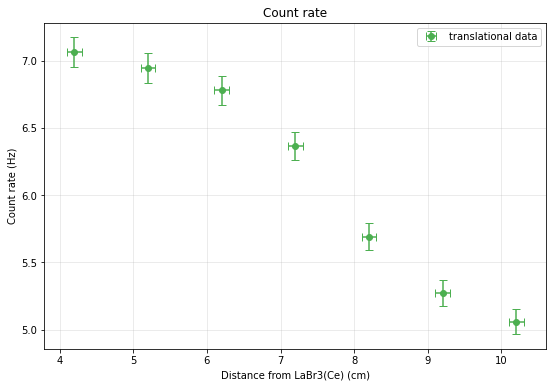

In [54]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(translationalx0[[0,1,2,5,6,7,8]], rated[[0,1,2,5,6,7,8]], xerr=0.1, yerr=rate_errd[[0,1,2,5,6,7,8]], fmt='o', color='#4CAF50', label='translational data', capsize=4)
plt.xlabel("Distance from LaBr3(Ce) (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### 18/03

In [55]:
t = []
for key in na22m:
    time = na22m[key]["time"]
    t.append(time)

In [56]:
time = np.array(t)
ratem = countsm/time
rate_errm = counts_errm/time
print(ratem)
print(rate_errm)
print(len(ratem))

[7.97162949 7.67345285 4.44066869 7.54675969 4.66821737 0.81676717
 7.88127636 0.69309529 0.47914623 0.80345448 4.83180893 0.89041696
 0.45235039 0.69655051 1.68278057 5.8049342  7.15595362 5.23309092
 1.54558173 0.72988467]
[0.17088526 0.16793688 0.13189107 0.16667453 0.1347468  0.07266534
 0.16999827 0.06976303 0.06443336 0.07235983 0.13675842 0.07434251
 0.06373309 0.06984845 0.09042081 0.14817917 0.16271147 0.14157952
 0.0878454  0.07063938]
20


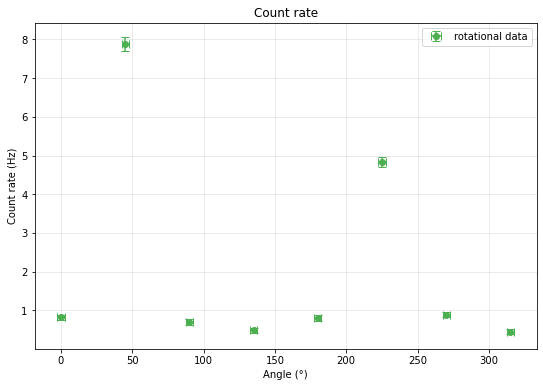

In [57]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(rotational, ratem[5:13], xerr=2.5, yerr=rate_errm[5:13], fmt='o', color='#4CAF50', label='rotational data', capsize=4)
plt.xlabel("Angle (°)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

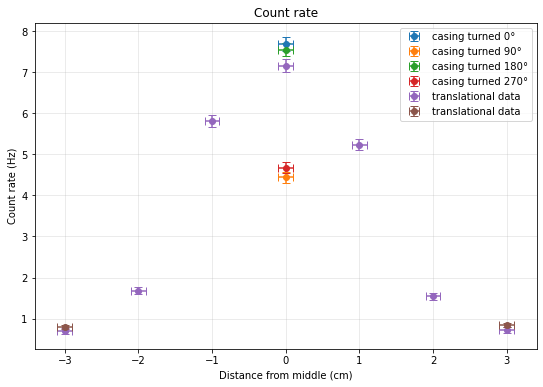

In [58]:
fig = plt.figure(figsize=(9,6))
plt.errorbar([0], ratem[1], xerr=0.1, yerr=rate_errm[1], fmt='o', label='casing turned 0°', capsize=4)
plt.errorbar([0], ratem[2], xerr=0.1, yerr=rate_errm[2], fmt='o', label='casing turned 90°', capsize=4)
plt.errorbar([0], ratem[3], xerr=0.1, yerr=rate_errm[3], fmt='o', label='casing turned 180°', capsize=4)
plt.errorbar([0], ratem[4], xerr=0.1, yerr=rate_errm[4], fmt='o', label='casing turned 270°', capsize=4)
plt.errorbar(translationaly, ratem[13:20], xerr=0.1, yerr=rate_errm[13:20], fmt='o', label='translational data', capsize=4)
plt.errorbar([3,-3], rated[3:5], xerr=0.1, yerr=rate_errd[3:5], fmt='o', label='translational data', capsize=4)
plt.xlabel("Distance from middle (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### 01/04

In [59]:
t = []
for key in na22a1:
    time = na22a1[key]["time"]
    t.append(time)

In [60]:
time = np.array(t)
ratea1 = countsa1/time
rate_erra1 = counts_erra1/time
print(ratea1)
print(rate_erra1)
print(len(ratea1))

[7.22442222 8.29767753 8.50563751 8.55554933 6.5156362  5.75339112
 5.16213088 5.0752768  1.52457692 0.75550371 5.42248467 1.68498285
 0.73878809 5.79691325]
[0.16394979 0.17455067 0.17653744 0.17700718 0.15655615 0.14819415
 0.14137337 0.14034347 0.08845818 0.07247914 0.14441418 0.09143792
 0.0720926  0.14868494]
14


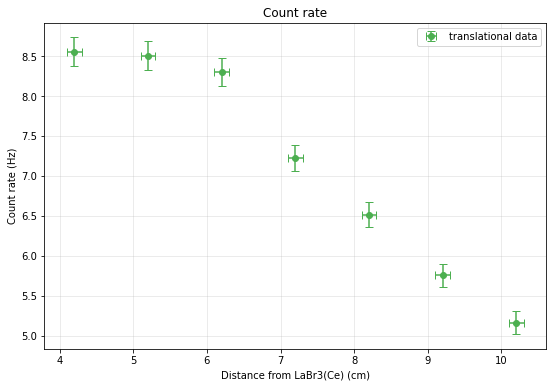

In [61]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(translationalx0a1, ratea1[0:7], xerr=0.1, yerr=rate_erra1[0:7], fmt='o', color='#4CAF50', label='translational data', capsize=4)
plt.xlabel("Distance from LaBr3(Ce) (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

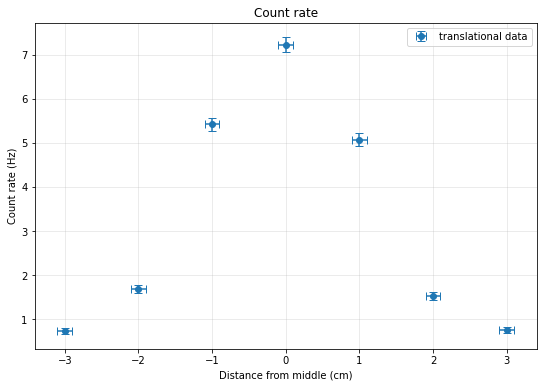

In [62]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(translationalya1, ratea1[[0,7,8,9,10,11,12]], xerr=0.1, yerr=rate_erra1[[0,7,8,9,10,11,12]], fmt='o', label='translational data', capsize=4)
plt.xlabel("Distance from middle (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### 22/04

In [63]:
t = []
for key in na22min10:
    time = na22min10[key]["time"]
    t.append(time)

In [64]:
time = np.array(t)
ratemin10 = countsmin10/time
rate_errmin10 = counts_errmin10/time
print(ratemin10)
print(rate_errmin10)
print(len(ratemin10))

[7.09231702 7.77659579 8.52746337 8.29349985 6.43951241 5.71337919
 5.0606918  5.03075589 1.47548896 0.75109343 5.57970143 1.784285
 0.76608354 0.81781656 7.6963152  0.79449021 0.51242126 0.77781617
 4.9506731  0.84623454 0.52908149 5.05829899 5.21915494 5.1243277
 3.77269227 3.81836757 3.78887525 0.52433916 0.54559731 0.62928151
 6.0481833  6.00142724 6.10203532]
[0.11415214 0.11904937 0.12420003 0.12261588 0.10927398 0.10357939
 0.09817929 0.09792542 0.06045785 0.04945758 0.10249545 0.06458006
 0.04970935 0.05057027 0.11848411 0.05018452 0.04525152 0.04990675
 0.09724082 0.05103779 0.04555717 0.21462826 0.13870359 0.09872051
 0.18778388 0.12064667 0.08669745 0.08942682 0.06012352 0.04735811
 0.2331722  0.1478305  0.10666296]
33


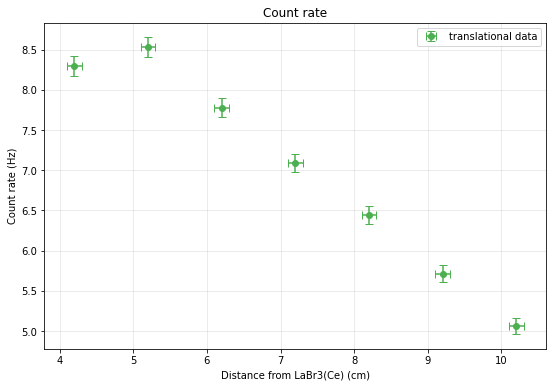

In [65]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(translationalx0min10, ratemin10[0:7], xerr=0.1, yerr=rate_errmin10[0:7], fmt='o', color='#4CAF50', label='translational data', capsize=4)
plt.xlabel("Distance from LaBr3(Ce) (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

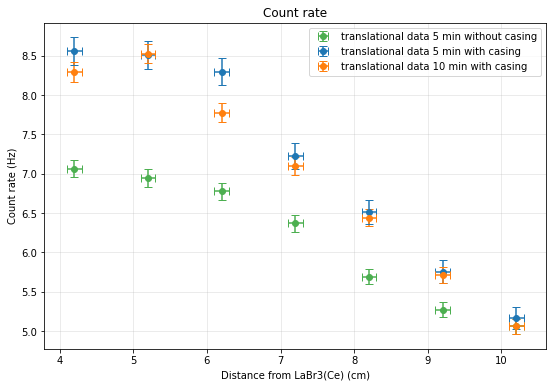

In [66]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(translationalx0[[0,1,2,5,6,7,8]], rated[[0,1,2,5,6,7,8]], xerr=0.1, yerr=rate_errd[[0,1,2,5,6,7,8]], fmt='o', color='#4CAF50', label='translational data 5 min without casing', capsize=4)
plt.errorbar(translationalx0a1, ratea1[0:7], xerr=0.1, yerr=rate_erra1[0:7], fmt='o', label='translational data 5 min with casing', capsize=4)
plt.errorbar(translationalx0min10, ratemin10[0:7], xerr=0.1, yerr=rate_errmin10[0:7], fmt='o', label='translational data 10 min with casing', capsize=4)
plt.xlabel("Distance from LaBr3(Ce) (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

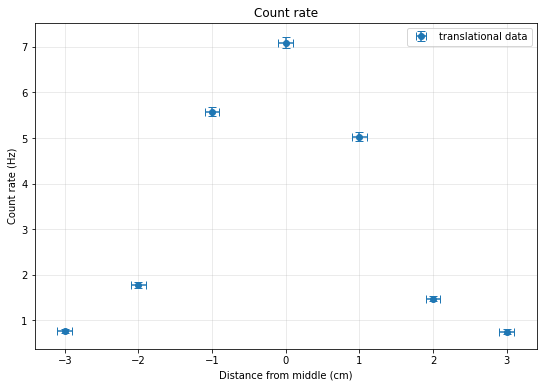

In [67]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(translationalymin10, ratemin10[[0,7,8,9,10,11,12]], xerr=0.1, yerr=rate_errmin10[[0,7,8,9,10,11,12]], fmt='o', label='translational data', capsize=4)
plt.xlabel("Distance from middle (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

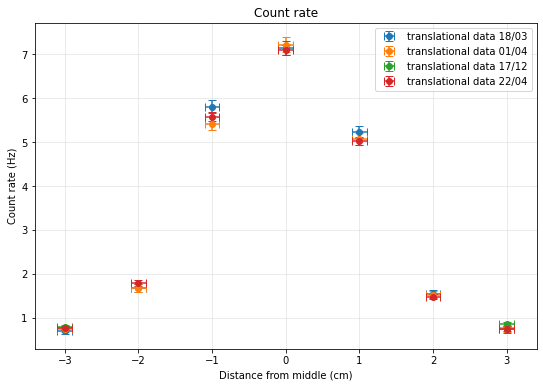

In [68]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(translationaly, ratem[13:20], xerr=0.1, yerr=rate_errm[13:20], fmt='o', label='translational data 18/03', capsize=4)
plt.errorbar(translationalya1, ratea1[[0,7,8,9,10,11,12]], xerr=0.1, yerr=rate_erra1[[0,7,8,9,10,11,12]], fmt='o', label='translational data 01/04', capsize=4)
plt.errorbar([3,-3], rated[3:5], xerr=0.1, yerr=rate_errd[3:5], fmt='o', label='translational data 17/12', capsize=4)
plt.errorbar(translationalymin10, ratemin10[[0,7,8,9,10,11,12]], xerr=0.1, yerr=rate_errmin10[[0,7,8,9,10,11,12]], fmt='o', label='translational data 22/04', capsize=4)
plt.xlabel("Distance from middle (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

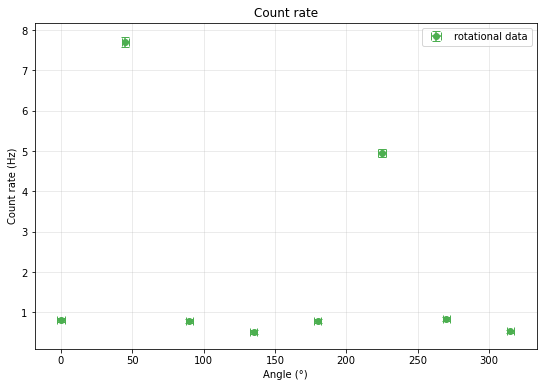

In [74]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(rotationalmin10, ratemin10[13:21], xerr=2.5, yerr=rate_errmin10[13:21], fmt='o', color='#4CAF50', label='rotational data', capsize=4)
plt.xlabel("Angle (°)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

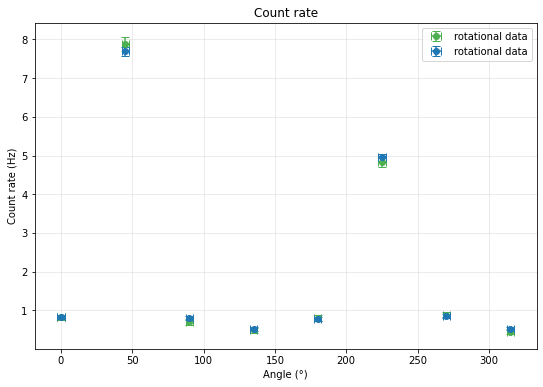

In [75]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(rotational, ratem[5:13], xerr=2.5, yerr=rate_errm[5:13], fmt='o', color='#4CAF50', label='rotational data', capsize=4)
plt.errorbar(rotationalmin10, ratemin10[13:21], xerr=2.5, yerr=rate_errmin10[13:21], fmt='o', label='rotational data', capsize=4)
plt.xlabel("Angle (°)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Translational fit

In [69]:
def coinc_trans(x, A, s1, s2):
    #CeBr3 solid angle 
    # distance from source to crystal
    d_sq = s2 - x
    # dimensions crystal 48mm x 48mm x 48mm
    a = 4.8/2
    b = 4.8/2
    # solid angle
    omega_sq = 4 * np.arctan((a * b) / (d_sq * np.sqrt(a**2 + b**2 + d_sq**2)))
    geom_factor_sq = omega_sq/(4*np.pi)

    #LaBr3(Ce)
    # distance from source to crystal
    d_cil = s1 - x + 0.26 # crystal is 2.6mm behind entrance window
    # radius crystal
    r = 3.81/2 #diameter cylinder: 38.1mm
    # solid angle
    omega_cil = 2*np.pi*(1-d_cil/(np.sqrt(d_cil**2+r**2)))
    geom_factor_cil = omega_cil/(4*np.pi)
    
    return A * geom_factor_sq * geom_factor_cil